### sql을 활용한 데이터분석

In [16]:
pip install pandas deep-translator tqdm

Note: you may need to restart the kernel to use updated packages.


In [30]:
import pandas as pd
from deep_translator import GoogleTranslator
from tqdm import tqdm

# pandas의 apply 메소드에 tqdm(진행 막대)을 연동시킵니다.
tqdm.pandas()

# --- 파일 경로 및 설정 ---
input_file = 'C:/Users/jmh98/Desktop/archive/review_(1_2).csv'
output_file = 'review_translated_ko.csv'
column_to_translate = 'review_comment_message'
# ---------------------

try:
    print(f"'{input_file}' 파일을 불러오는 중입니다...")
    # 구조가 깨진 줄은 경고 후 건너뛰고, 'latin-1' 인코딩으로 파일을 읽습니다.
    df = pd.read_csv(input_file, on_bad_lines='warn', encoding='latin-1')
    print("✅ 파일 읽기 성공!")

    # 번역할 열이 파일에 있는지 확인합니다.
    if column_to_translate in df.columns:
        print(f"✅ '{column_to_translate}' 열을 찾았습니다. 번역을 준비합니다.")

        # NaN (빈 값)을 번역 오류 방지를 위해 빈 문자열로 바꿉니다.
        df[column_to_translate] = df[column_to_translate].fillna('')

        # 번역기 객체를 생성합니다 (포르투갈어 -> 한국어).
        translator = GoogleTranslator(source='pt', target='ko')

        # 텍스트 번역을 위한 함수를 정의합니다.
        def translate_text(text):
            # 텍스트가 비어있지 않은 문자열일 경우에만 번역을 시도합니다.
            if isinstance(text, str) and text.strip():
                try:
                    return translator.translate(text)
                except Exception as e:
                    # 번역 중 오류가 발생하면 원본 텍스트를 반환합니다.
                    return text
            return '' # 비어있는 값은 그대로 둡니다.

        print("\n번역을 시작합니다. 데이터 양에 따라 시간이 걸릴 수 있습니다...")
        # 'progress_apply'를 사용하여 진행 막대와 함께 번역 함수를 적용합니다.
        df['review_message_ko'] = df[column_to_translate].progress_apply(translate_text)

        print(f"\n번역된 데이터를 '{output_file}' 파일로 저장하는 중입니다...")
        # 결과를 새 CSV 파일로 저장합니다.
        df.to_csv(output_file, index=False, encoding='utf-8-sig')

        print(f"\n✨ 작업 완료! 번역된 내용이 '{output_file}' 파일에 성공적으로 저장되었습니다.")

    else:
        print(f"🔴 [오류] 파일에서 '{column_to_translate}' 열을 찾을 수 없습니다.")
        print("\n현재 파일에 있는 열 목록:")
        print(list(df.columns))

except Exception as e:
    print(f"🔴 [오류] 파일을 처리하는 중 예상치 못한 문제가 발생했습니다:")
    print(f"-> {e}")

C:\Users\jmh98\AppData\Local\Temp\ipykernel_18732\465392213.py:17: ParserWarning: Skipping line 597: expected 2 fields, saw 3
Skipping line 654: expected 2 fields, saw 3
Skipping line 1036: expected 2 fields, saw 3
Skipping line 1091: expected 2 fields, saw 3
Skipping line 1104: expected 2 fields, saw 3
Skipping line 1212: expected 2 fields, saw 3
Skipping line 1230: expected 2 fields, saw 3
Skipping line 1337: expected 2 fields, saw 3
Skipping line 1531: expected 2 fields, saw 3
Skipping line 2117: expected 2 fields, saw 3
Skipping line 2255: expected 2 fields, saw 3
Skipping line 2436: expected 2 fields, saw 4
Skipping line 2504: expected 2 fields, saw 5
Skipping line 2817: expected 2 fields, saw 3
Skipping line 2998: expected 2 fields, saw 4
Skipping line 3164: expected 2 fields, saw 5
Skipping line 3321: expected 2 fields, saw 3
Skipping line 3332: expected 2 fields, saw 3
Skipping line 3847: expected 2 fields, saw 3
Skipping line 3899: expected 2 fields, saw 4
Skipping line 4990: 

'C:/Users/jmh98/Desktop/archive/review_(1_2).csv' 파일을 불러오는 중입니다...
✅ 파일 읽기 성공!
✅ 'review_comment_message' 열을 찾았습니다. 번역을 준비합니다.

번역을 시작합니다. 데이터 양에 따라 시간이 걸릴 수 있습니다...


100%|██████████| 10863/10863 [4:53:30<00:00,  1.62s/it]    


번역된 데이터를 'review_translated_ko.csv' 파일로 저장하는 중입니다...

✨ 작업 완료! 번역된 내용이 'review_translated_ko.csv' 파일에 성공적으로 저장되었습니다.


In [31]:
pip install pandas konlpy scikit-learn


   ---------------------------------------- 0.0/19.4 MB ? eta -:--:--
   --------------- ------------------------ 7.3/19.4 MB 37.1 MB/s eta 0:00:01
   ---------------------- ----------------- 11.0/19.4 MB 26.8 MB/s eta 0:00:01
   ---------------------------------------- 19.4/19.4 MB 32.4 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [konlpy]
   ---------------------------------------- 2/2 [konlpy]



In [4]:
pip install wordcloud

In [6]:
# 1. NLTK 라이브러리 설치 (터미널이나 주피터 노트북 셀에서 실행)
!pip install nltk

# 2. NLTK 데이터 다운로드 (Python 코드 내에서 실행)
import nltk
nltk.download('stopwords') # 불용어 사전 다운로드
nltk.download('punkt')     # 토큰화 도구 다운로드

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jmh98\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jmh98\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [8]:
import nltk

# 문장 분리를 위한 'punkt' 패키지 다운로드
nltk.download('punkt')

# 불용어(stopwords) 사전을 위한 'stopwords' 패키지 다운로드
nltk.download('stopwords')

print("NLTK 데이터 다운로드가 완료되었습니다. 이제 메인 코드를 실행할 수 있습니다.")

NLTK 데이터 다운로드가 완료되었습니다. 이제 메인 코드를 실행할 수 있습니다.


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jmh98\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jmh98\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [21]:
import csv

# --- 설정 ---
# 1. 수정하고 싶은 원본 파일의 이름을 정확하게 입력하세요.
input_file_name = 'C:/Users/jmh98/Desktop/archive/reviews.1-2.csv' 

# 2. 새로 저장될 파일의 이름을 지정하세요.
output_file_name = 'reviews_cleaned.csv'

# 3. 쉼표를 제거할 열의 이름을 지정하세요.
target_column_name = 'review_comment_message'
# --- 설정 끝 ---


try:
    with open(input_file_name, 'r', encoding='cp949', errors='ignore') as infile, \
         open(output_file_name, 'w', encoding='utf-8', newline='') as outfile:

        reader = csv.reader(infile)
        writer = csv.writer(outfile)

        # 헤더(첫 줄)를 읽고, 수정할 열의 위치(인덱스)를 찾습니다.
        header = next(reader)
        writer.writerow(header)
        
        try:
            message_column_index = header.index(target_column_name)
        except ValueError:
            print(f"오류: '{target_column_name}' 열을 파일에서 찾을 수 없습니다.")
            exit()

        # 나머지 데이터 줄을 하나씩 처리합니다.
        for row in reader:
            try:
                # 해당 열의 내용에서 모든 쉼표(,)를 찾아 제거합니다.
                if len(row) > message_column_index:
                    row[message_column_index] = row[message_column_index].replace(',', '')
                writer.writerow(row)
            except IndexError:
                # 행의 구조가 잘못된 경우 건너뜁니다.
                print(f"경고: 구조가 잘못된 행을 건너뜁니다 -> {row}")
                continue

    print("-" * 50)
    print(f"✅ 작업 완료!")
    print(f"'{input_file_name}' 파일의 '{target_column_name}' 열에서 쉼표를 모두 제거하고,")
    print(f"'{output_file_name}' 파일로 성공적으로 저장했습니다.")
    print("-" * 50)


except FileNotFoundError:
    print(f"오류: 원본 파일인 '{input_file_name}'을 찾을 수 없습니다.")
    print("스크립트와 동일한 폴더에 파일이 있는지 확인해주세요.")
except Exception as e:
    print(f"작업 중 예상치 못한 오류가 발생했습니다: {e}")


--------------------------------------------------
✅ 작업 완료!
'C:/Users/jmh98/Desktop/archive/reviews.1-2.csv' 파일의 'review_comment_message' 열에서 쉼표를 모두 제거하고,
'reviews_cleaned.csv' 파일로 성공적으로 저장했습니다.
--------------------------------------------------


In [56]:
import pandas as pd
import re
from collections import Counter

# 1. CSV 불러오기
file_path = "C:/Users/jmh98/Desktop/archive/reviews.1-2.csv"

# 인코딩 문제 대비 (utf-8, latin1, cp1252 순차 시도)
for enc in ["utf-8", "latin1", "cp1252", "ISO-8859-1"]:
    try:
        df = pd.read_csv(file_path, encoding=enc)
        break
    except:
        continue

# 2. 텍스트 합치기 (제목+본문)
df["text"] = df[["review_comment_title", "review_comment_message"]].fillna("").agg(" ".join, axis=1)

# 3. 소문자 변환 + 특수문자 제거
text = " ".join(df["text"]).lower()
text = re.sub(r"[^a-zà-úÀ-Ú0-9\s]", " ", text)

# 4. 토큰화
tokens = text.split()

# 5. 불용어 제거
stopwords = set([
    "de","da","do","das","dos","em","na","no","nas","nos",
    "para","por","com","sem","uma","um","uns","umas",
    "o","a","os","as","e","é","foi","ser","está","estao",
    "ao","aos","se","que","já","mais","menos","muito",
    "pouco","mas","entao","porque","quando","onde","como"
])
tokens = [t for t in tokens if t not in stopwords and len(t) > 2]

# 6. Trigram 만들기
trigrams = [f"{tokens[i]} {tokens[i+1]} {tokens[i+2]}" for i in range(len(tokens)-2)]

# 불용어/짧은 단어 포함된 trigram 제외
def ok_trigram(tg):
    w1, w2, w3 = tg.split()
    for w in (w1, w2, w3):
        if len(w) <= 2:
            return False
    return True

trigrams = [tg for tg in trigrams if ok_trigram(tg)]

# 7. 상위 50개 추출
tri_counter = Counter(trigrams)
top50_trigrams = tri_counter.most_common(50)

# 8. DataFrame으로 정리
tri_df = pd.DataFrame(top50_trigrams, columns=["trigram_pt", "frequency"])
print(tri_df.head(50))   # 상위 50개 출력

# 9. CSV로 저장 (선택)
tri_df.to_csv("top50_trigrams.csv", index=False, encoding="utf-8-sig")


                   trigram_pt  frequency
0          recebi meu produto        208
1        ainda recebi produto        184
2          meu dinheiro volta        125
3          nao recebi produto        110
4          quero meu dinheiro         82
5        produto veio defeito         65
6      produto ainda entregue         62
7      recebi produto comprei         60
8            ainda nao recebi         60
9        recebi produto ainda         59
10           ainda recebi meu         58
11       produto ainda chegou         58
12    produto ssima qualidade         54
13      comprei dois produtos         49
14         meu produto chegou         49
15      recebi produto errado         49
16     recebi produto produto         48
17           minha resid ncia         47
18     produto recebi produto         47
19           meu produto veio         46
20      recebi produto recebi         46
21        produto veio errado         45
22   produto entregue produto         40
23       meu pro

In [55]:
top_words

[('produto', 6143),
 ('recebi', 3261),
 ('comprei', 1876),
 ('veio', 1538),
 ('entrega', 1400),
 ('ainda', 1387),
 ('entregue', 1319),
 ('chegou', 1171),
 ('nao', 948),
 ('prazo', 904),
 ('compra', 903),
 ('pedido', 786),
 ('loja', 770),
 ('dia', 764),
 ('agora', 686),
 ('est', 575),
 ('apenas', 539),
 ('lannister', 536),
 ('quero', 514),
 ('nada', 512),
 ('produtos', 511),
 ('site', 509),
 ('pois', 507),
 ('dois', 501),
 ('contato', 463),
 ('dias', 434),
 ('outro', 432),
 ('qualidade', 428),
 ('aguardando', 422),
 ('pra', 419),
 ('fiz', 390),
 ('momento', 377),
 ('nota', 362),
 ('correios', 350),
 ('vel', 348),
 ('paguei', 342),
 ('recomendo', 341),
 ('resposta', 335),
 ('duas', 333),
 ('receber', 321),
 ('diferente', 319),
 ('dinheiro', 313),
 ('aguardo', 312),
 ('retorno', 307),
 ('problema', 306),
 ('pedi', 304),
 ('ter', 293),
 ('empresa', 279),
 ('entregaram', 279),
 ('vou', 276),
 ('saber', 274),
 ('hoje', 274),
 ('errado', 274),
 ('troca', 273),
 ('devolu', 272),
 ('mercadoria'

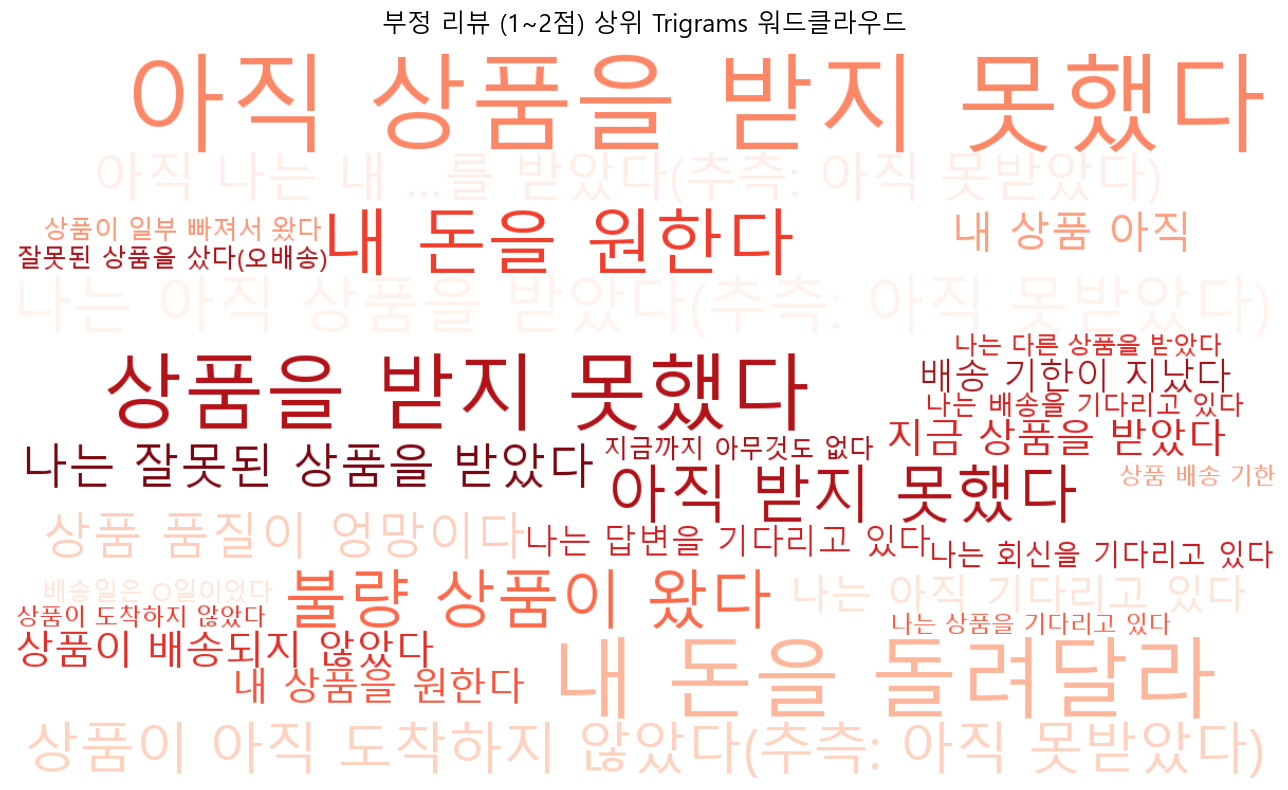

Saved: C:/Users/jmh98/Desktop/archive/top_trigrams_wordcloud_ko_red.png


In [79]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import unicodedata as ud
import re

# === 1) CSV 로드 (인코딩 자동 시도) ===
path = r"C:/Users/jmh98/Desktop/archive/top50_trigrams.csv"
for enc in ["utf-8-sig", "utf-8", "cp949", "euc-kr", "latin1", "cp1252", "ISO-8859-1"]:
    try:
        df = pd.read_csv(path, encoding=enc)
        break
    except Exception:
        pass

# === 2) 컬럼/값 클린업 ===
df.columns = [c.strip().replace("\ufeff","") for c in df.columns]
need = {"translation_ko", "frequency"}
if not need.issubset(df.columns):
    raise ValueError(f"필수 컬럼 누락: {need - set(df.columns)} / 현재 컬럼: {df.columns.tolist()}")

# 한글 정규화(NFC) + 공백 제거
df["translation_ko"] = (
    df["translation_ko"]
      .astype(str).str.strip()
      .apply(lambda s: ud.normalize("NFC", s))
)

# frequency 숫자화 (천단위 콤마/공백 제거 후 변환)
def to_number(x):
    if pd.isna(x): return None
    s = str(x).strip()
    s = re.sub(r"[,\s]", "", s)   # 쉼표/공백 제거
    return pd.to_numeric(s, errors="coerce")

df["frequency"] = df["frequency"].apply(to_number)

# 결측/빈 문자열 제거
df = df.dropna(subset=["translation_ko", "frequency"])
df = df[df["translation_ko"] != ""]
df = df[df["frequency"] > 0]

# 같은 번역 문구끼리 합산
agg = (
    df.groupby("translation_ko", as_index=False)["frequency"]
      .sum()
      .sort_values("frequency", ascending=False)
)

if agg.empty:
    raise ValueError("유효한 translation_ko/ frequency가 없습니다. 원본 CSV를 확인하세요.")

freq_dict = dict(zip(agg["translation_ko"], agg["frequency"]))

# === 3) 워드클라우드 (빨강 계열, 한글 폰트) ===
font_path = r"C:/Windows/Fonts/malgun.ttf"  # 한글 폰트
wc = WordCloud(
    width=1200, height=700,
    background_color="white",
    colormap="Reds",            # ✅ 빨강 계열 팔레트
    prefer_horizontal=1.0,
    font_path=font_path
).generate_from_frequencies(freq_dict)

# 제목도 한글 폰트 지정
title_font = fm.FontProperties(fname=font_path, size=18)

plt.figure(figsize=(14, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("부정 리뷰 (1~2점) 상위 Trigrams 워드클라우드", fontproperties=title_font)
plt.tight_layout()
plt.show()

# 저장
out_path = r"C:/Users/jmh98/Desktop/archive/top_trigrams_wordcloud_ko_red.png"
wc.to_file(out_path)
print("Saved:", out_path)


사용 가능한 컬럼: ['trigram_pt', 'frequency', 'translation_ko']


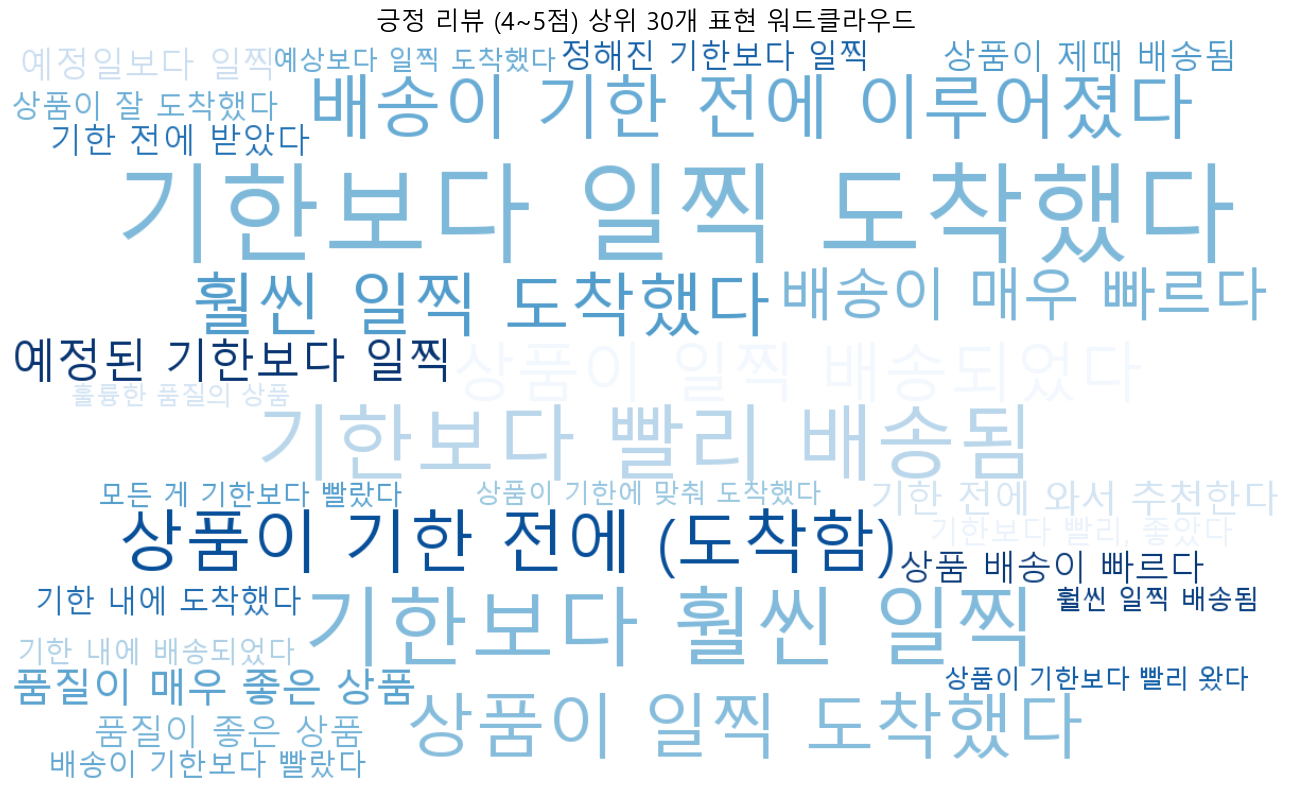

Saved: C:/Users/jmh98/Desktop/archive/top30_trigrams_4-5_wordcloud_blue.png


In [77]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import unicodedata as ud

# === 1) CSV 로드 ===
CSV_PATH = r"C:/Users/jmh98/Desktop/archive/top50_trigrams_4-5.csv"
df = None
for enc in ["utf-8-sig","utf-8","cp949","euc-kr","latin1","cp1252","ISO-8859-1"]:
    try:
        df = pd.read_csv(CSV_PATH, encoding=enc)
        break
    except Exception:
        pass
if df is None:
    raise ValueError("CSV 파일을 불러오지 못했습니다.")

# === 2) 컬럼 확인/정리 ===
df.columns = [c.strip().replace("\ufeff","") for c in df.columns]
print("사용 가능한 컬럼:", df.columns.tolist())
if "translation_ko" not in df.columns:
    raise ValueError("'translation_ko' 컬럼이 없습니다. CSV 내용을 확인하세요.")

# === 3) 텍스트 정규화 + frequency 숫자화 ===
df["translation_ko"] = (
    df["translation_ko"]
      .astype(str)
      .str.strip()
      .apply(lambda s: ud.normalize("NFC", s))   # 한글 정규화
)
df["frequency"] = pd.to_numeric(df["frequency"], errors="coerce")

df = df.dropna(subset=["translation_ko","frequency"])
df = df[df["translation_ko"]!=""]
df = df[df["frequency"]>0]

# === 4) 상위 30개만 사용 ===
df = df.sort_values("frequency", ascending=False).head(30)
freq_dict = dict(zip(df["translation_ko"], df["frequency"]))

# === 5) 워드클라우드 생성 (블루 계열) ===
FONT_PATH = r"C:/Windows/Fonts/malgun.ttf"   # 한글 폰트
wc = WordCloud(
    width=1200, height=700,
    background_color="white",
    colormap="Blues",           # ✅ 블루 계열 팔레트
    prefer_horizontal=1.0,
    font_path=FONT_PATH
).generate_from_frequencies(freq_dict)

# === 6) 출력 ===
title_font = fm.FontProperties(fname=FONT_PATH, size=18)
plt.figure(figsize=(14,8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("긍정 리뷰 (4~5점) 상위 30개 표현 워드클라우드", fontproperties=title_font)
plt.tight_layout()
plt.show()

# === 7) 저장 ===
out_path = r"C:/Users/jmh98/Desktop/archive/top30_trigrams_4-5_wordcloud_blue.png"
wc.to_file(out_path)
print("Saved:", out_path)


인코딩 성공: cp949
그래프 저장 완료: C:/Users/jmh98/Desktop/archive/bad_complaint_category.png


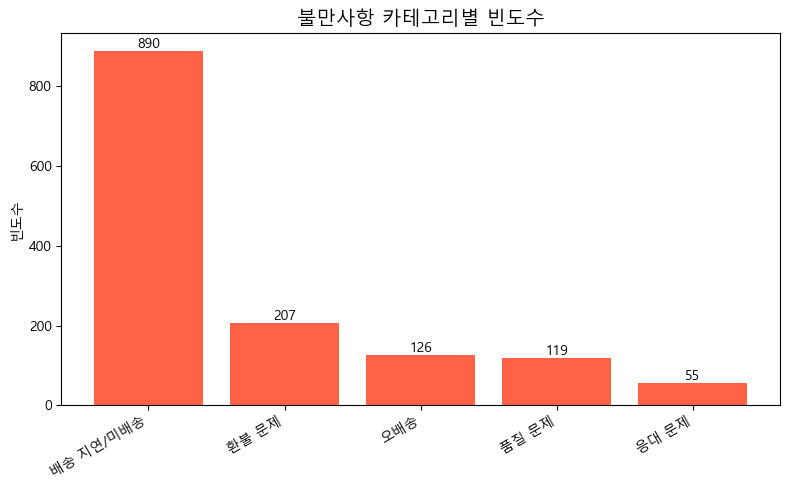

In [105]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1) CSV 불러오기 (인코딩 자동 시도) ===
file_path = "C:/Users/jmh98/Desktop/archive/top50_trigrams.csv"
encodings = ["utf-8-sig", "utf-8", "cp949", "euc-kr", "latin1", "ISO-8859-1"]
df = None
for enc in encodings:
    try:
        df = pd.read_csv(file_path, encoding=enc)
        print(f"인코딩 성공: {enc}")
        break
    except Exception:
        continue
if df is None:
    raise ValueError("CSV 파일을 불러오지 못했습니다.")

# === 2) 카테고리명 정규화 ===
mapping = {
    "배송지연/미배송": "배송 지연/미배송",
    "배송 지연/미배송": "배송 지연/미배송",
    "품질문제": "품질 문제",
    "환불문제": "환불 문제",
    "오 배송": "오배송"
}
if "problem" not in df.columns:
    raise ValueError(f"problem 컬럼 없음. 현재 컬럼: {df.columns.tolist()}")

df["problem"] = df["problem"].replace(mapping)

# === 3) 빈도 합산 ===
df_grouped = (
    df.groupby("problem", as_index=False)["frequency"]
      .sum()
      .sort_values("frequency", ascending=False)
)

# === 4) 폰트 설정 (윈도우 기준) ===
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# === 5) 그래프 그리기 ===
plt.figure(figsize=(8,5))
bars = plt.bar(df_grouped["problem"], df_grouped["frequency"], color="tomato")
plt.xticks(rotation=30, ha="right")
plt.title("불만사항 카테고리별 빈도수", fontsize=14)
plt.ylabel("빈도수")

# 막대 위에 값 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{int(height)}", 
             ha="center", va="bottom", fontsize=10)

plt.tight_layout()

# === 6) 그래프 저장 ===
save_path = "C:/Users/jmh98/Desktop/archive/bad_complaint_category.png"
plt.savefig(save_path, dpi=300)   # 300dpi 고해상도
print(f"그래프 저장 완료: {save_path}")
 
plt.show()


인코딩 성공: cp949
그래프 저장 완료: C:/Users/jmh98/Desktop/archive/불만사항 카테고리별 빈도수.png


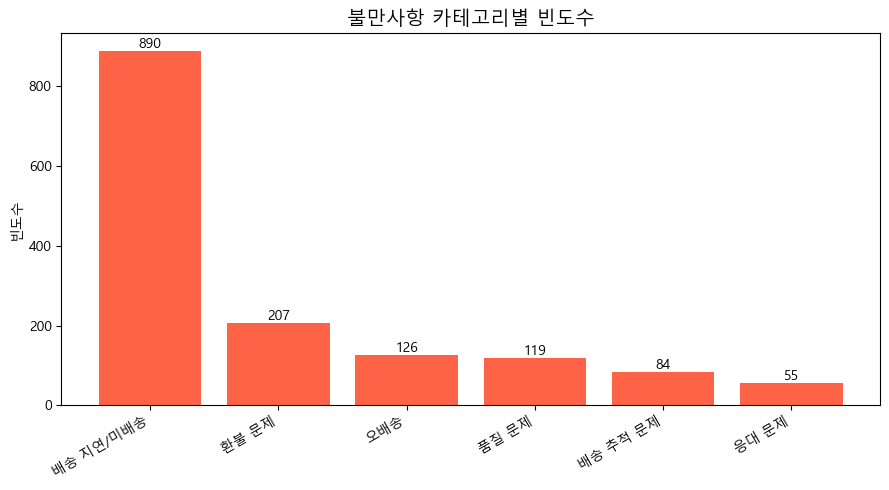

In [143]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1) CSV 불러오기 (인코딩 자동 시도) ===
file_path = "C:/Users/jmh98/Desktop/archive/top50_trigrams.csv"
encodings = ["utf-8-sig", "utf-8", "cp949", "euc-kr", "latin1", "ISO-8859-1"]
df = None
for enc in encodings:
    try:
        df = pd.read_csv(file_path, encoding=enc)
        print(f"인코딩 성공: {enc}")
        break
    except Exception:
        continue
if df is None:
    raise ValueError("CSV 파일을 불러오지 못했습니다.")

# === 2) 카테고리명 정규화 ===
mapping = {
    "배송지연/미배송": "배송 지연/미배송",
    "배송 지연/미배송": "배송 지연/미배송",
    "품질문제": "품질 문제",
    "환불문제": "환불 문제",
    "오 배송": "오배송",
    # 배송 추적 관련 표현 통일
    "배송추적문제": "배송 추적 문제",
    "배송 추적문제": "배송 추적 문제",
    "배송 추적 이슈": "배송 추적 문제",
    "배송조회 문제": "배송 추적 문제",
}
if "problem" not in df.columns or "frequency" not in df.columns:
    raise ValueError(f"필수 컬럼 누락. 현재 컬럼: {df.columns.tolist()}")

df["problem"] = df["problem"].replace(mapping)
df["frequency"] = pd.to_numeric(df["frequency"], errors="coerce").fillna(0).astype(int)

# === 3) '배송 추적 문제: 84건' 추가(기존에 있으면 합계로 반영됨) ===
add_problem, add_freq = "배송 추적 문제", 84
df_extra = pd.DataFrame([{"problem": add_problem, "frequency": add_freq}])
df = pd.concat([df, df_extra], ignore_index=True)

# === 4) 빈도 합산 ===
df_grouped = (
    df.groupby("problem", as_index=False)["frequency"]
      .sum()
      .sort_values("frequency", ascending=False)
)

# === 5) 폰트 설정 (윈도우 기준) ===
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# === 6) 그래프 그리기 ===
plt.figure(figsize=(9,5))
bars = plt.bar(df_grouped["problem"], df_grouped["frequency"], color="tomato")
plt.xticks(rotation=30, ha="right")
plt.title("불만사항 카테고리별 빈도수", fontsize=14)
plt.ylabel("빈도수")

# 막대 위에 값 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{int(height)}",
             ha="center", va="bottom", fontsize=10)

plt.tight_layout()

# === 7) 그래프 저장 ===
save_path = "C:/Users/jmh98/Desktop/archive/불만사항 카테고리별 빈도수.png"
plt.savefig(save_path, dpi=300)
print(f"그래프 저장 완료: {save_path}")

plt.show()


❌ 실패: utf-8-sig / 'utf-8' codec can't decode byte 0xb1 in position 68: invalid start byte
❌ 실패: utf-8 / 'utf-8' codec can't decode byte 0xb1 in position 0: invalid start byte
✅ 인코딩 성공: cp949
컬럼: ['trigram_pt', 'frequency', 'translation_ko', 'reason']
좋음 품질 카테고리 비중: 0.00%
그래프 저장 완료: C:/Users/jmh98/Desktop/archive/top29_good_review_ratio.png


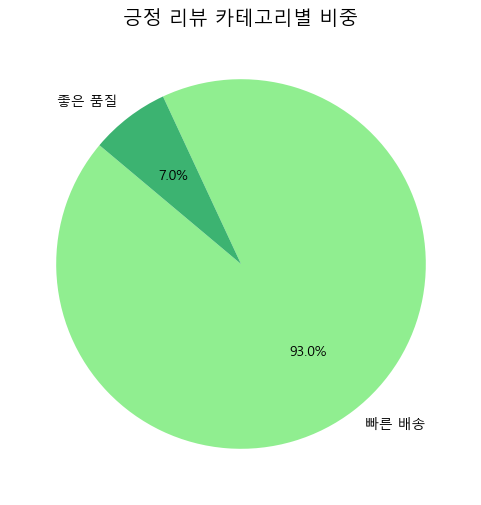

In [140]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1) CSV 불러오기 (인코딩 자동 시도) ===
file_path = r"C:/Users/jmh98/Desktop/archive/top50_trigrams_4-5.csv"
encodings = ["utf-8-sig","utf-8","cp949","euc-kr","latin1","ISO-8859-1"]
df = None
for enc in encodings:
    try:
        df = pd.read_csv(file_path, encoding=enc)
        print(f"✅ 인코딩 성공: {enc}")
        print("컬럼:", df.columns.tolist())
        break
    except Exception as e:
        print(f"❌ 실패: {enc} / {e}")
        continue
if df is None:
    raise ValueError("CSV 파일을 불러오지 못했습니다.")

# === 2) 카테고리 매핑 ===
mapping = {
    "배송 빠름": "배송",
    "배송": "배송",
    "추천": "추천/만족",
    "추천/만족": "추천/만족",
    "좋음 품질": "품질",
    "품질": "품질",
    "포장": "포장"
}
df["category"] = df["reason"].replace(mapping)

# === 3) 카테고리별 frequency 합산 ===
df_grouped = (
    df.groupby("category", as_index=False)["frequency"]
      .sum()
      .sort_values("frequency", ascending=False)
)

# === 4) 전체 대비 '품질' 비중 ===
total_freq = df_grouped["frequency"].sum()
quality_freq = df_grouped.loc[df_grouped["category"]=="품질","frequency"].sum()
quality_pct = (quality_freq / total_freq) * 100
print(f"좋음 품질 카테고리 비중: {quality_pct:.2f}%")

# === 5) 그래프 (파이차트, 초록 계열) ===
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(6,6))
colors = ["lightgreen","mediumseagreen","palegreen","darkseagreen"]

plt.pie(
    df_grouped["frequency"],
    labels=df_grouped["category"],
    autopct="%1.1f%%",
    startangle=140,
    colors=colors
)
plt.title("긍정 리뷰 카테고리별 비중", fontsize=14)

# === 6) 그래프 저장 ===
save_path = r"C:/Users/jmh98/Desktop/archive/top29_good_review_ratio.png"
plt.savefig(save_path, dpi=300)
print(f"그래프 저장 완료: {save_path}")

plt.show()


그래프 저장 완료: C:/Users/jmh98/Desktop/archive/top29_good_review_ratio.png


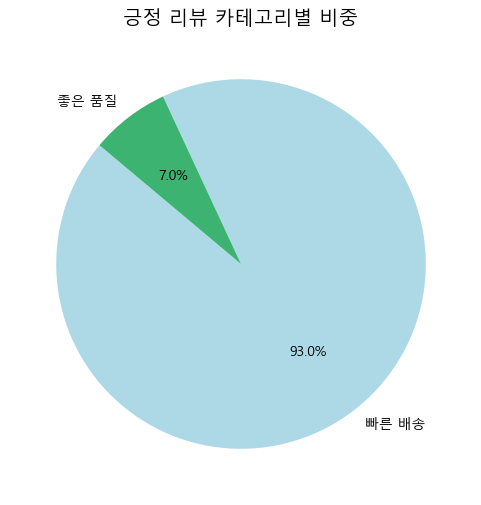

In [104]:
# 카테고리별 색상 매핑 (추천)
color_map = {
    "좋은 품질": "mediumseagreen",  # 품질 → 부드러운 녹색
    "빠른 배송": "lightblue"     # 배송 → 밝은 하늘색
}

colors = [color_map.get(cat, "gray") for cat in df_grouped["category"]]

plt.figure(figsize=(6,6))
plt.pie(
    df_grouped["frequency"],
    labels=df_grouped["category"],
    autopct="%1.1f%%",
    startangle=140,
    colors=colors
)
plt.title("긍정 리뷰 카테고리별 비중", fontsize=14)

save_path = r"C:/Users/jmh98/Desktop/archive/top29_good_review_ratio.png"
plt.savefig(save_path, dpi=300)
print(f"그래프 저장 완료: {save_path}")

plt.show()


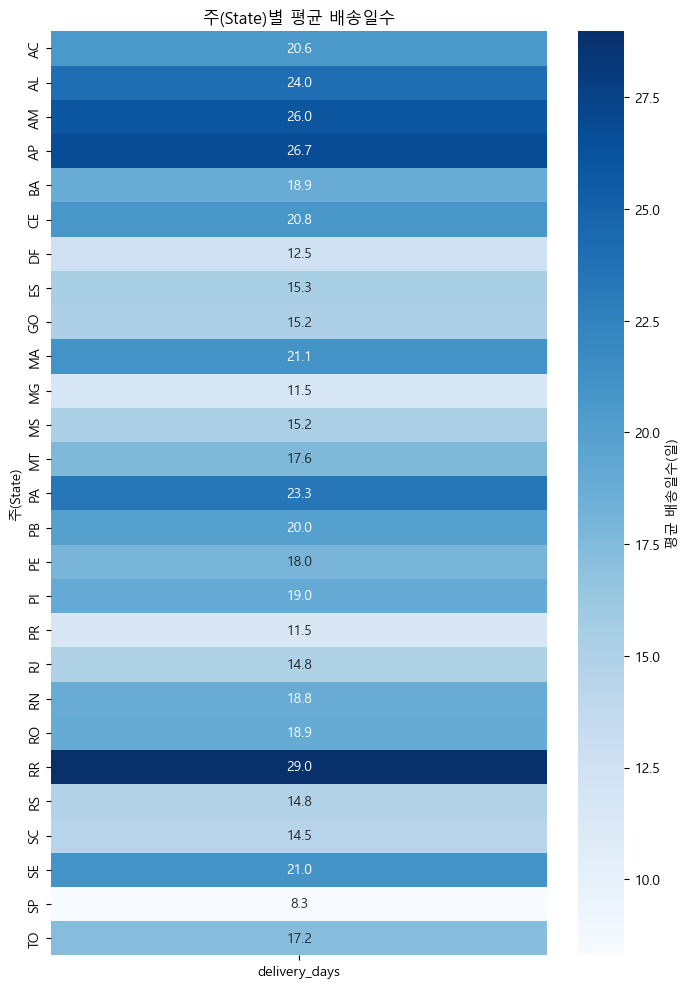

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# 1. 데이터 불러오기
# ======================
orders = pd.read_csv("C:/Users/jmh98/Desktop/archive/olist_orders_dataset.csv")
customers = pd.read_csv("C:/Users/jmh98/Desktop/archive/olist_customers_dataset.csv")

# ======================
# 2. 날짜 처리
# ======================
# object 타입을 datetime으로 변환
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

# 배송일수 계산 (배송 완료일 - 주문일)
orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days

# ======================
# 3. orders와 customers 매핑
# ======================
# order_id ↔ customer_id 연결
df = pd.merge(orders, customers, on='customer_id', how='inner')

# ======================
# 4. 주(state)별 평균 배송일수 계산
# ======================
state_delivery = df.groupby('customer_state')['delivery_days'].mean().reset_index()

# ======================
# 5. 히트맵 시각화
# ======================
# pivot 형태로 변환 (가로=state, 세로=1행짜리 dummy)
state_delivery_pivot = state_delivery.pivot_table(index="customer_state", values="delivery_days")

plt.figure(figsize=(8,12))
sns.heatmap(state_delivery_pivot, annot=True, fmt=".1f", cmap="Blues", cbar_kws={'label': '평균 배송일수(일)'})
plt.title("주(State)별 평균 배송일수")
plt.ylabel("주(State)")
plt.xlabel("")
plt.show
plt.savefig("주(State)별 평균 배송일수")


In [112]:
CREATE TABLE olist_geolocation_dataset (
    geolocation_zip_code_prefix VARCHAR(10),
    geolocation_lat DECIMAL(10,6),
    geolocation_lng DECIMAL(10,6),
    geolocation_city VARCHAR(100),
    geolocation_state VARCHAR(10)
);

LOAD DATA LOCAL INFILE 'C:/Users/jmh98/Desktop/archive/olist_geolocation_dataset.csv'
INTO TABLE olist_geolocation_dataset
FIELDS TERMINATED BY ','
ENCLOSED BY '"'
LINES TERMINATED BY '\n'
IGNORE 1 ROWS;


SyntaxError: invalid syntax (2412500416.py, line 1)

In [120]:
import pandas as pd
import numpy as np

# ✅ 쉼표 없애고, parse_dates를 read_csv의 인자로 넣기
orders = pd.read_csv(
    r"C:\Users\jmh98\Desktop\archive\olist_orders_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ]
)

# 2) 처리시간(일) 계산: 승인 → 택배사 인계
df = orders.copy()
df["handling_days"] = (
    df["order_delivered_carrier_date"] - df["order_approved_at"]
) / np.timedelta64(1, "D")

# 3) 정상/유효 데이터만 남기기: 배송완료 & 값 존재 & 음수 제거
ok = df[
    (df["order_status"] == "delivered")
    & df["handling_days"].notna()
    & (df["handling_days"] >= 0)
].copy()

# ---------- 임계값 설정 ----------
USE_PERCENTILE = True   # True면 백분위수 기준, False면 고정 일수 기준
PERC = 0.90             # 상위 10%를 "오래 걸림"으로 보기
FIXED_DAYS = 2.0        # False일 때 사용할 고정 임계값(예: 2일)

if USE_PERCENTILE:
    threshold = ok["handling_days"].quantile(PERC)
    crit_desc = f"P{int(PERC*100)}={threshold:.2f}일"
else:
    threshold = FIXED_DAYS
    crit_desc = f"{FIXED_DAYS:.2f}일(고정)"

# 4) '오래 걸린 주문' 비율 계산
ok["is_long"] = (ok["handling_days"] > threshold).astype(int)
long_rate = ok["is_long"].mean() * 100

print("=== 처리시간 기준 요약 ===")
print(f"- 유효 주문 수: {len(ok):,}건")
print(f"- 임계값: {crit_desc}")
print(f"- 오래 걸린 주문 비율: {long_rate:.2f}%")
print()
print("처리시간 기초통계(일):")
print(ok["handling_days"].describe([0.5, 0.9, 0.95]).round(2))


=== 처리시간 기준 요약 ===
- 유효 주문 수: 95,113건
- 임계값: P90=6.02일
- 오래 걸린 주문 비율: 10.00%

처리시간 기초통계(일):
count    95113.00
mean         2.85
std          3.49
min          0.00
50%          1.85
90%          6.02
95%          8.15
max        125.76
Name: handling_days, dtype: float64


=== 처리시간 기준 요약 ===
- 유효 주문 수: 95,113건
- 임계값: P90=6.02일
- 오래 걸린 주문 비율: 10.00%

▶ 월별 오래 걸림 비율 (상위 12개월 미리보기):
           ym     n  long_rate  long_rate_pct
11 2017-09-01  4136   0.089458           8.95
12 2017-10-01  4478   0.112774          11.28
13 2017-11-01  7288   0.136800          13.68
14 2017-12-01  5508   0.124546          12.45
15 2018-01-01  7045   0.108162          10.82
16 2018-02-01  6543   0.119059          11.91
17 2018-03-01  7001   0.090701           9.07
18 2018-04-01  6409   0.072866           7.29
19 2018-05-01  6681   0.076486           7.65
20 2018-06-01  5976   0.066600           6.66
21 2018-07-01  5596   0.103288          10.33
22 2018-08-01  6266   0.072455           7.25


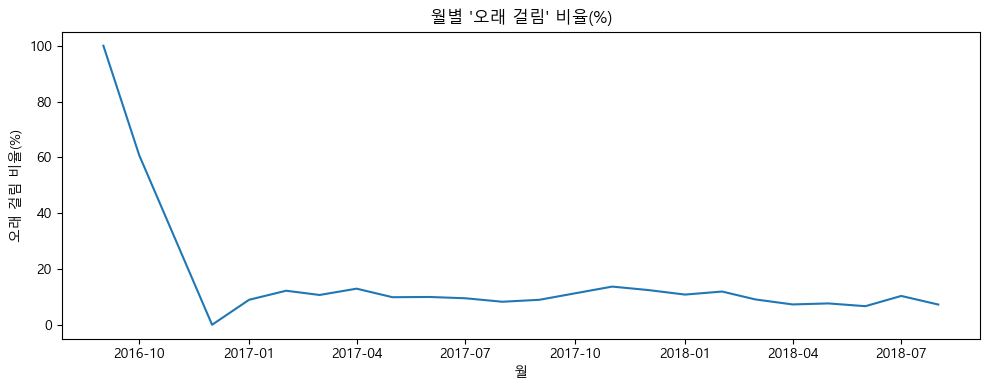


▶ 셀러별 오래 걸림 비율 TOP 10 (표본수 ≥ 50 )
                             seller_id      seller_city seller_state  orders  \
274   17f51e7198701186712e53a39c564617        sao paulo           SP      56   
930   5058e8c1e82653974541e83690655b4a  itaquaquecetuba           SP      62   
1475  7c67e1448b00f6e969d365cea6b010ab  itaquaquecetuba           SP     973   
1308  6fd52c528dcb38be2eea044946b811f8        sao paulo           SP      67   
1957  a7f13822ceb966b076af67121f87b063  itaquaquecetuba           SP      73   
537   2eb70248d66e0e3ef83659f71b244378         campinas           SP     187   
381   213b25e6f54661939f11710a6fddb871            salto           SP     150   
996   54965bbe3e4f07ae045b90b0b8541f52    foz do iguacu           PR      71   
1561  8444e55c1f13cd5c179851e5ca5ebd00        congonhal           MG      92   
2568  dd7ddc04e1b6c2c614352b383efe2d36        sao paulo           SP     120   

      long_rate_pct  
274           94.64  
930           90.32  
1475          88.0

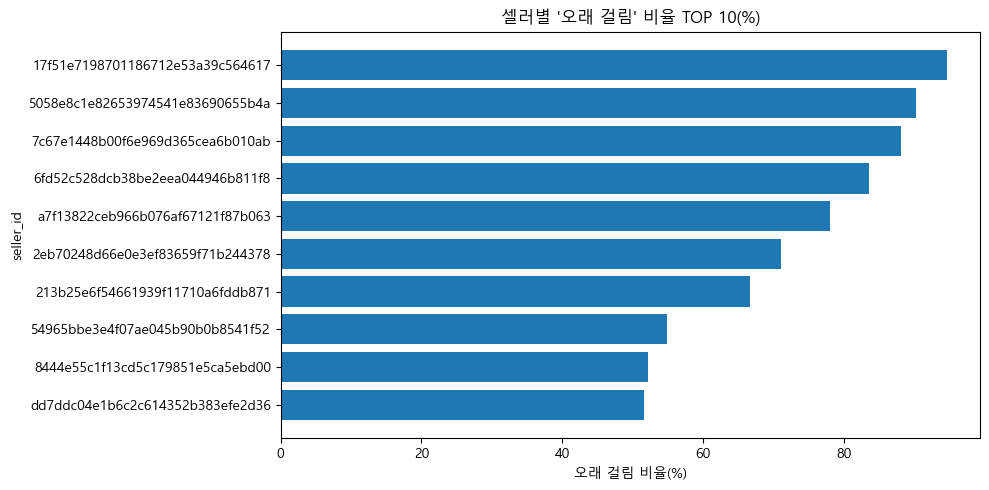

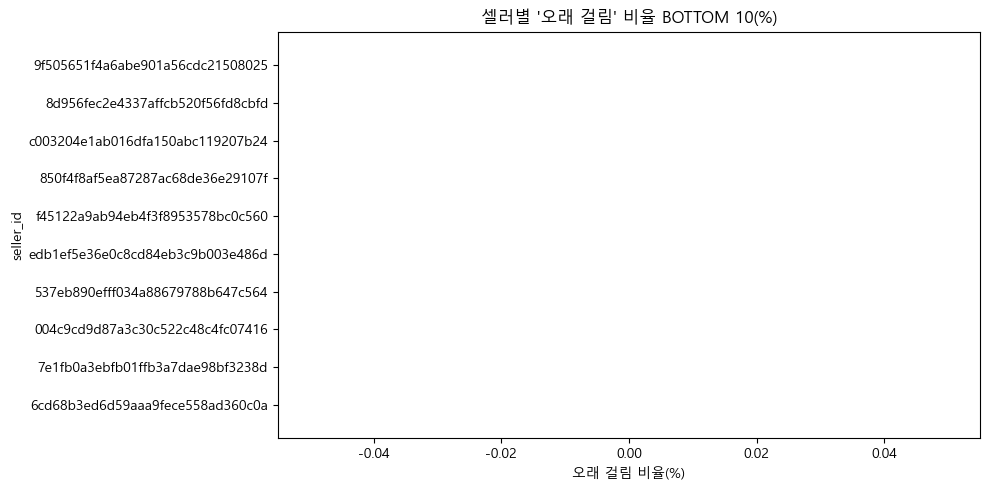

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===== 0) 경로와 옵션 =====
PATH = r"C:\Users\jmh98\Desktop\archive"
USE_PERCENTILE = True   # True면 백분위수(PERC) 기준, False면 고정 일수(FIXED_DAYS)
PERC = 0.90             # 상위 10%를 '오래 걸림'으로
FIXED_DAYS = 2.0        # USE_PERCENTILE=False일 때 임계값
MIN_ORDERS_PER_SELLER = 50  # 셀러 랭킹에서 최소 표본수(노이즈 제거)

# ===== 1) 데이터 로드 =====
orders = pd.read_csv(
    fr"{PATH}\olist_orders_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
)
order_items = pd.read_csv(fr"{PATH}\olist_order_items_dataset.csv")
sellers = pd.read_csv(fr"{PATH}\olist_sellers_dataset.csv")

# ===== 2) 처리시간 계산 & 유효 표본 필터 =====
df = orders.copy()
df["handling_days"] = (
    df["order_delivered_carrier_date"] - df["order_approved_at"]
) / np.timedelta64(1, "D")

ok = df[
    (df["order_status"] == "delivered")
    & df["handling_days"].notna()
    & (df["handling_days"] >= 0)
].copy()

# ===== 3) 임계값 & '오래 걸림' 플래그 =====
if USE_PERCENTILE:
    threshold = ok["handling_days"].quantile(PERC)
    crit_desc = f"P{int(PERC*100)}={threshold:.2f}일"
else:
    threshold = FIXED_DAYS
    crit_desc = f"{FIXED_DAYS:.2f}일(고정)"

ok["is_long"] = (ok["handling_days"] > threshold).astype(int)

print("=== 처리시간 기준 요약 ===")
print(f"- 유효 주문 수: {len(ok):,}건")
print(f"- 임계값: {crit_desc}")
print(f"- 오래 걸린 주문 비율: {ok['is_long'].mean()*100:.2f}%")
print()

# ===== 4) (A) 월별 ‘오래 걸림’ 비율 추이 =====
ok["ym"] = ok["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
monthly = (
    ok.groupby("ym", as_index=False)
      .agg(n=("order_id", "size"), long_rate=("is_long", "mean"))
      .assign(long_rate_pct=lambda d: (d["long_rate"]*100).round(2))
)
print("▶ 월별 오래 걸림 비율 (상위 12개월 미리보기):")
print(monthly.tail(12))

# 간단 라인차트
plt.figure(figsize=(10, 4))
plt.plot(monthly["ym"], monthly["long_rate_pct"])
plt.title("월별 '오래 걸림' 비율(%)")
plt.xlabel("월")
plt.ylabel("오래 걸림 비율(%)")
plt.tight_layout()
plt.show()

# ===== 5) (B) 셀러별 오래 걸림 비율 Top/Bottom 10 =====
# 주문-셀러 매핑: 한 주문에 여러 셀러가 있을 수 있으니 (order_id, seller_id) 중복 제거
order_seller = order_items[["order_id", "seller_id"]].drop_duplicates()

# 주문 수준의 is_long을 셀러에 전파(단순화된 방법)
ok_seller = order_seller.merge(ok[["order_id", "is_long"]], on="order_id", how="inner")

seller_stats = (
    ok_seller.groupby("seller_id", as_index=False)
             .agg(orders=("order_id", "size"), long_rate=("is_long", "mean"))
             .assign(long_rate_pct=lambda d: (d["long_rate"]*100).round(2))
)

# 셀러 메타(도시/주) 붙이기
seller_stats = seller_stats.merge(
    sellers[["seller_id", "seller_city", "seller_state"]],
    on="seller_id", how="left"
)

# 최소 표본수 필터
ss_f = seller_stats[seller_stats["orders"] >= MIN_ORDERS_PER_SELLER].copy()

top10 = ss_f.sort_values(["long_rate", "orders"], ascending=[False, False]).head(10)
bottom10 = ss_f.sort_values(["long_rate", "orders"], ascending=[True, False]).head(10)

print("\n▶ 셀러별 오래 걸림 비율 TOP 10 (표본수 ≥", MIN_ORDERS_PER_SELLER, ")")
print(top10[["seller_id","seller_city","seller_state","orders","long_rate_pct"]])

print("\n▶ 셀러별 오래 걸림 비율 BOTTOM 10 (표본수 ≥", MIN_ORDERS_PER_SELLER, ")")
print(bottom10[["seller_id","seller_city","seller_state","orders","long_rate_pct"]])

# (선택) 막대 그래프: Top10
plt.figure(figsize=(10, 5))
plt.barh(top10["seller_id"].astype(str), top10["long_rate_pct"])
plt.gca().invert_yaxis()
plt.title("셀러별 '오래 걸림' 비율 TOP 10(%)")
plt.xlabel("오래 걸림 비율(%)"); plt.ylabel("seller_id")
plt.tight_layout(); plt.show()

# (선택) 막대 그래프: Bottom10
plt.figure(figsize=(10, 5))
plt.barh(bottom10["seller_id"].astype(str), bottom10["long_rate_pct"])
plt.gca().invert_yaxis()
plt.title("셀러별 '오래 걸림' 비율 BOTTOM 10(%)")
plt.xlabel("오래 걸림 비율(%)"); plt.ylabel("seller_id")
plt.tight_layout(); plt.show()


In [122]:
m = ok.copy()
m["ym"] = m["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
monthly = (m.groupby("ym", as_index=False)
             .agg(n=("order_id","size"), long_rate=("is_long","mean")))
monthly["long_rate_pct"] = monthly["long_rate"]*100

print(monthly.head(12))  # 초기 몇 달 n이 매우 작을 것

# 소표본 제거(예: n<200 제외)
monthly_f = monthly[monthly["n"]>=200].copy()


           ym     n  long_rate  long_rate_pct
0  2016-09-01     1   1.000000     100.000000
1  2016-10-01   265   0.607547      60.754717
2  2016-12-01     1   0.000000       0.000000
3  2017-01-01   748   0.089572       8.957219
4  2017-02-01  1640   0.121951      12.195122
5  2017-03-01  2546   0.106834      10.683425
6  2017-04-01  2279   0.129443      12.944274
7  2017-05-01  3531   0.098839       9.883886
8  2017-06-01  3131   0.099649       9.964867
9  2017-07-01  3852   0.095016       9.501558
10 2017-08-01  4192   0.082538       8.253817
11 2017-09-01  4136   0.089458       8.945841


In [126]:
# === 배송추적 문제 탐지 + 요약 ===
# 경로: C:\Users\jmh98\Desktop\archive

import pandas as pd
import numpy as np
import re

# Unidecode가 없으면 먼저 설치(주피터):  !pip install Unidecode
try:
    from unidecode import unidecode
except Exception as e:
    raise RuntimeError("Unidecode 패키지를 먼저 설치하세요:  !pip install Unidecode") from e

# --------------------------
# 0) 경로
# --------------------------
PATH = r"C:\Users\jmh98\Desktop\archive"
ORDERS_CSV  = fr"{PATH}\olist_orders_dataset.csv"
REVIEWS_CSV = fr"{PATH}\olist_order_reviews_dataset.csv"
ITEMS_CSV   = fr"{PATH}\olist_order_items_dataset.csv"  # (옵션) 셀러 분석할 때 사용

# --------------------------
# 1) 리뷰 로드 & 텍스트 정규화
# --------------------------
reviews = pd.read_csv(REVIEWS_CSV)
if "review_comment_message" not in reviews.columns:
    raise ValueError("리뷰 파일에 'review_comment_message' 컬럼이 없습니다.")

def normalize_text(s):
    if pd.isna(s):
        return ""
    s = str(s).lower()
    s = unidecode(s)                    # não -> nao 등 악센트 제거
    s = re.sub(r"\s+", " ", s).strip()
    return s

df_rev = reviews.copy()
df_rev["msg_norm"] = df_rev["review_comment_message"].apply(normalize_text)

# --------------------------
# 2) 규칙 기반 패턴(부정 + 추적)
# --------------------------
NEG     = r"(nao|sem|nunca|nenhum|nao consigo|nao funciona|nao atualiza|nao aparece|erro|link quebrado)"
TRK     = r"(rastre|rastrei|rastrea|rastreament|acompanhar|acompanhament|codigo de rastreio|numero de rastreio|track|tracking|link de rastreio)"
NEG_KO  = r"(안돼|안되|못하|모르겠|안 보이|안됨|먹통|오류|에러|안떠|안 뜨|안나오|안 나와)"
TRK_KO  = r"(추적|배송조회|배송 추적|송장|운송장|트래킹|링크|코드)"

WINDOW_CHARS = 40  # 부정/추적 사이 허용 거리
WINDOW = rf".{{0,{WINDOW_CHARS}}}"

pattern_core = re.compile(
    rf"(({NEG}{WINDOW}{TRK})|({TRK}{WINDOW}{NEG})|({NEG_KO}{WINDOW}{TRK_KO})|({TRK_KO}{WINDOW}{NEG_KO}))",
    flags=re.IGNORECASE
)

# '정상 동작' 가드(있으면 제외)
OK = r"(consegui|funcionou|funciona|ok|deu certo|normal)"
ok_guard = re.compile(rf"({TRK}{WINDOW}{OK}|{OK}{WINDOW}{TRK})", flags=re.IGNORECASE)

def flag_tracking_issue(text):
    if not text:
        return 0
    hit = bool(pattern_core.search(text))
    if not hit:
        return 0
    if ok_guard.search(text):
        return 0
    return 1

df_rev["tracking_issue"] = df_rev["msg_norm"].apply(flag_tracking_issue)

# --------------------------
# 3) 요약(리뷰 자체)
# --------------------------
tot = len(df_rev)
has_msg = df_rev["msg_norm"].str.len().gt(0).sum()
issue_cnt = int(df_rev["tracking_issue"].sum())
issue_rate = (issue_cnt / has_msg * 100) if has_msg else 0.0

print("=== 리뷰 기준 요약 ===")
print(f"- 리뷰 전체: {tot:,}건 / 메시지 있는 리뷰: {has_msg:,}건")
print(f"- '배송추적 문제' 탐지: {issue_cnt:,}건 ({issue_rate:.2f}% of messaged reviews)")

# (선택) 샘플 확인
print("\n[샘플 10건]")
cols_show = [c for c in ["review_id","order_id","review_score","review_comment_message"] if c in df_rev.columns]
print(df_rev.loc[df_rev["tracking_issue"]==1, cols_show].head(10))

# =====================================================================
# 4) (옵션) 주문 데이터와 결합해 '지연/평점'과의 연계 보기
#     - 이미 ok DF가 있다면, 아래 4-1)~4-2) 대신 그 DF를 사용해도 됩니다.
# =====================================================================

# 4-1) 주문 로드 & 처리시간/지연 파생
orders = pd.read_csv(
    ORDERS_CSV,
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
)

df = orders.copy()
df["handling_days"] = (
    df["order_delivered_carrier_date"] - df["order_approved_at"]
) / np.timedelta64(1, "D")
df["is_late"] = (df["order_delivered_customer_date"] > df["order_estimated_delivery_date"]).astype(int)

ok = df[
    (df["order_status"] == "delivered")
    & df["handling_days"].notna()
    & (df["handling_days"] >= 0)
].copy()

# 4-2) 리뷰 결합 후 비교(지연 vs 정시 / 평점별)
rev2 = df_rev[["order_id","review_score","tracking_issue"]].copy()
merged = ok.merge(rev2, on="order_id", how="left")

rate_all    = merged["tracking_issue"].fillna(0).mean()*100
rate_late   = merged.loc[merged["is_late"]==1, "tracking_issue"].fillna(0).mean()*100
rate_ontime = merged.loc[merged["is_late"]==0, "tracking_issue"].fillna(0).mean()*100

print("\n=== 지연/정시 별 '추적문제' 언급률(주문 기준) ===")
print(f"- 전체: {rate_all:.2f}%")
print(f"- 지연 주문: {rate_late:.2f}%")
print(f"- 정시 주문: {rate_ontime:.2f}%")

by_score = (merged.groupby("review_score", dropna=False)["tracking_issue"]
                 .mean().mul(100).round(2))
print("\n=== 평점별 '추적문제' 언급률(%) ===")
print(by_score)

# (선택) 결과 저장
OUT_CSV = fr"{PATH}\tracking_issue_flagged_reviews.csv"
df_rev.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
print(f"\n[저장 완료] {OUT_CSV}")


=== 리뷰 기준 요약 ===
- 리뷰 전체: 99,224건 / 메시지 있는 리뷰: 40,932건
- '배송추적 문제' 탐지: 120건 (0.29% of messaged reviews)

[샘플 10건]
                             review_id                          order_id  \
241   43992f6d75ecc01ddd8c748b9362bc81  55b5a2fb966c36bed46f082ad6062914   
419   341ccd0a62b82793121e9ebdd1eafaf9  adad66be45caa015d25e03ed17610197   
1874  9a51d1c482e096296f0fffc70686bd16  a65fde0b04e8ca23f84e79c9935e3b93   
4782  bf1fc2818227fe4c46191d38b21af385  83ce5e6768db49face91c92a88888ea1   
5103  22bdc97e28061b06997f11e29f0a4594  24da4d9782584b90078fc30af8df32ad   
5129  a85844696a9ca32d9222920582e2d8a9  c349154248a3236a01cba7d40dbef250   
5142  378b4c91b5d825b2b05df4323bbd20e9  4af2fb154881f350d8696f7f7a7f80d3   
5363  a2f7c0a48ecfdcf5662ac767ca9529fb  47b3fc542306133e109f00371870c632   
5433  c429a534b9bf33d921930e8e7f8f4719  4a4ded48a84c0cee9a190dd22ce96866   
5764  e851100a62534ac1ece796a5e5476d27  f790aa049bfa6a4143c96ad40711c558   

      review_score                             re

In [139]:
import os, time

# --- 유틸: PATH가 폴더인지/파일인지 자동 판별해서 저장 폴더를 결정 ---
def resolve_out_dir(path_like: str) -> str:
    """path_like가 폴더면 그대로, 파일이면 그 폴더, 비정상이면 현재 작업폴더"""
    if path_like and os.path.isdir(path_like):
        return path_like
    if path_like and os.path.isfile(path_like):
        return os.path.dirname(os.path.abspath(path_like))
    # 파일 경로처럼 보이지만 아직 존재하지 않는 경우(확장자 포함 등)도 파일로 간주
    if path_like and os.path.splitext(os.path.basename(path_like))[1]:
        return os.path.dirname(os.path.abspath(path_like)) or os.getcwd()
    return os.getcwd()

# --- 유틸: 안전 저장 (잠금 시 타임스탬프 붙여 다른 이름으로) ---
def safe_save_csv(df, out_path, encoding="utf-8-sig"):
    out_dir = os.path.dirname(out_path)
    os.makedirs(out_dir, exist_ok=True)
    try:
        df.to_csv(out_path, index=False, encoding=encoding)
        print(f"[저장 완료] {out_path}")
    except PermissionError:
        ts = time.strftime("%Y%m%d_%H%M%S")
        alt = os.path.join(out_dir, f"{os.path.splitext(os.path.basename(out_path))[0]}.{ts}.csv")
        print(f"[경고] 파일 잠금으로 저장 실패 → 다른 이름으로 저장합니다: {alt}")
        df.to_csv(alt, index=False, encoding=encoding)
    except OSError as e:
        print(f"[오류] {e} → 현재 작업 폴더에 저장 시도")
        ts = time.strftime("%Y%m%d_%H%M%S")
        alt = os.path.join(os.getcwd(), f"reviews.1-2.tracking_issue_only.{ts}.csv")
        df.to_csv(alt, index=False, encoding=encoding)
        print(f"[저장 완료] {alt}")

# --- 개수/비율 출력(0 나눗셈 방지) ---
def pct(a, b):
    return 0.0 if b == 0 else a / b * 100

n_low_issue = len(low_issue)
n_low_msg   = df_rev[(df_rev["review_score"].isin([1,2])) & (df_rev["review_comment_message"].astype(str).str.strip().ne(""))].shape[0]
n_low_all   = df_rev[df_rev["review_score"].isin([1,2])].shape[0]

print(f"1–2점 중 '배송추적 이슈' 건수: {n_low_issue:,}건")
print(f" - (분모1) message 있는 1–2점 대비: {pct(n_low_issue, n_low_msg):.2f}%  [{n_low_issue}/{n_low_msg}]")
print(f" - (분모2) 1–2점 전체 대비:        {pct(n_low_issue, n_low_all):.2f}%  [{n_low_issue}/{n_low_all}]")

# --- 저장 경로 결정 & 저장 ---
# PATH가 폴더든 파일이든 OK. 예: r"C:\Users\...\archive" 또는 r"C:\Users\...\reviews.1-2.message_notnull.csv"
out_dir  = resolve_out_dir(PATH)
out_path = os.path.join(out_dir, "reviews.1-2.tracking_issue_only.csv")
safe_save_csv(low_issue, out_path)


1–2점 중 '배송추적 이슈' 건수: 84건
 - (분모1) message 있는 1–2점 대비: 0.58%  [84/14574]
 - (분모2) 1–2점 전체 대비:        0.58%  [84/14575]
[저장 완료] C:\Users\jmh98\Desktop\archive\reviews.1-2.tracking_issue_only.csv


In [137]:
# === 1–2점 리뷰 중 '배송추적 이슈'만 추려 저장 (경로 안전 버전) ===
import os, re
import pandas as pd
from unidecode import unidecode  # 없으면 !pip install Unidecode

# 0) 입력 파일(확장자 없을 수도 있어서 둘 다 시도)
BASE = r"C:\Users\jmh98\Desktop\archive\reviews.1-2.message_notnull"
CANDIDATES = [BASE, BASE + ".csv"]

# 1) 읽기 (여러 인코딩 시도)
df, load_path = None, None
for p in CANDIDATES:
    if not os.path.exists(p):
        continue
    for enc in ["utf-8-sig", "cp949", "euc-kr", "latin1"]:
        try:
            df = pd.read_csv(p, encoding=enc)
            load_path = p
            print(f"[OK] Loaded: {p} (encoding={enc})")
            break
        except UnicodeDecodeError:
            continue
    if df is not None:
        break
if df is None:
    raise FileNotFoundError("입력 파일을 찾지 못했습니다. 실제 파일 경로/확장자를 확인하세요.")

# 2) 텍스트 정규화
def norm(s):
    if pd.isna(s): return ""
    s = unidecode(str(s).lower())
    return re.sub(r"\s+", " ", s).strip()

if "review_comment_message" not in df.columns:
    raise KeyError("컬럼 'review_comment_message'가 없습니다.")
df["msg_norm"] = df["review_comment_message"].map(norm)

# 3) 배송추적 이슈 플래그(부정 + 추적 키워드 근접)
NEG     = r"(nao|sem|nunca|nenhum|nao consigo|nao funciona|nao atualiza|nao aparece|erro|link quebrado)"
TRK     = r"(rastre|rastrei|rastrea|rastreament|acompanhar|acompanhament|codigo de rastreio|numero de rastreio|track|tracking|link de rastreio)"
NEG_KO  = r"(안돼|안되|못하|모르겠|안 보이|안됨|먹통|오류|에러|안떠|안 뜨|안나오|안 나와)"
TRK_KO  = r"(추적|배송조회|배송\s?추적|송장|운송장|트래킹|링크|코드)"
WINDOW  = r".{0,40}"

pattern_core = re.compile(
    rf"(({NEG}{WINDOW}{TRK})|({TRK}{WINDOW}{NEG})|({NEG_KO}{WINDOW}{TRK_KO})|({TRK_KO}{WINDOW}{NEG_KO}))",
    re.IGNORECASE
)
ok_guard = re.compile(
    rf"({TRK}{WINDOW}(consegui|funcionou|funciona|ok|deu certo|normal)|"
       r"(consegui|funcionou|funciona|ok|deu certo|normal){WINDOW}{TRK})",
    re.IGNORECASE
)

def flag_tracking_issue(t: str) -> int:
    if not t: return 0
    if not pattern_core.search(t): return 0
    if ok_guard.search(t): return 0
    return 1

df["tracking_issue"] = df["msg_norm"].map(flag_tracking_issue)

# 4) 1–2점 + 메시지 존재 + 이슈=1만 필터
mask_msg = df["msg_norm"].str.len().gt(0)
mask_low = df["review_score"].isin([1, 2]) if "review_score" in df.columns else True
low_issue = df[mask_msg & mask_low & df["tracking_issue"].eq(1)].copy()

# 5) 요약
n_all = len(df)
n_msg = int(mask_msg.sum())
n_low_all = int((df["review_score"].isin([1,2])).sum()) if "review_score" in df.columns else 0
n_low_msg = int((mask_msg & df["review_score"].isin([1,2])).sum()) if "review_score" in df.columns else 0
n_issue_all = int(df["tracking_issue"].sum())
n_low_issue = len(low_issue)

print("\n=== 요약 ===")
print(f"- 전체 행: {n_all:,} / 메시지 있는 행: {n_msg:,}")
print(f"- 배송추적 이슈(전체): {n_issue_all:,}")
if n_low_all:
    print(f"- 1–2점 전체: {n_low_all:,} / 메시지 있는 1–2점: {n_low_msg:,}")
    print(f"- 1–2점 중 '추적이슈': {n_low_issue:,}건 "
          f"({(n_low_issue/n_low_msg*100):.2f}% of msg-available 1–2점)")

# 6) 저장(입력 파일과 같은 폴더에 저장)
out_dir = os.path.dirname(load_path)
os.makedirs(out_dir, exist_ok=True)
out_csv = os.path.join(out_dir, "reviews.1-2.tracking_issue_only.csv")
low_issue.to_csv(out_csv, index=False, encoding="utf-8-sig")
print(f"[저장 완료] {out_csv}")


[OK] Loaded: C:\Users\jmh98\Desktop\archive\reviews.1-2.message_notnull.csv (encoding=utf-8-sig)

=== 요약 ===
- 전체 행: 10,891 / 메시지 있는 행: 10,890
- 배송추적 이슈(전체): 24
[저장 완료] C:\Users\jmh98\Desktop\archive\reviews.1-2.tracking_issue_only.csv


In [132]:
import pandas as pd

PATH = r"C:\Users\jmh98\Desktop\archive"
CSV  = fr"{PATH}\reviews.1-2.csv"

# 인코딩 자동 시도
for enc in ["utf-8-sig", "cp949", "euc-kr", "latin1"]:
    try:
        df = pd.read_csv(CSV, encoding=enc)
        print(f"[OK] encoding={enc}")
        break
    except UnicodeDecodeError:
        continue
else:
    raise RuntimeError("지원 인코딩으로 파일을 읽지 못했습니다.")

# review_comment_message NOT NULL만 추출
result = df[df["review_comment_message"].notna()].copy()

print(f"원본: {len(df):,}건 / 추출: {len(result):,}건")

# (선택) 저장
OUT = fr"{PATH}\reviews.1-2.message_notnull.csv"
result.to_csv(OUT, index=False, encoding="utf-8-sig")
print(f"[저장 완료] {OUT}")


[OK] encoding=cp949
원본: 14,602건 / 추출: 10,891건
[저장 완료] C:\Users\jmh98\Desktop\archive\reviews.1-2.message_notnull.csv


[OK] Loaded: C:\Users\jmh98\Desktop\archive\reviews.1-2.message_notnull.csv (encoding=utf-8-sig)

=== 배송추적 문제 리뷰 요약 ===
- 메시지 있는 표본: 10,890건
- 추적 이슈 탐지: 20건 (0.18%)

[추적 이슈 샘플 20건]
                              review_id                          order_id  \
208    9a51d1c482e096296f0fffc70686bd16  a65fde0b04e8ca23f84e79c9935e3b93   
941    b0991e2673cd0b872a40dac5f44187e8  03f4fbe820830f14931ffa4631cb0912   
1459   b16179e88e9e42d5684f5d76b0d1bb05  30d069e8fe27dc74e756bbb4f470a361   
1826   d6a5ec076e4c05013876308faf6cdc8b  a3b14686446d3401d67a3421891c34a3   
2496   95385692bbbb89edff61546aee200d73  9e8d7ab8137bcd3cfeac577dddf35592   
2972   17131fac50a38ec052bdb826a50aef7c  4ccbbab8f710965493ad65dc986dd9c2   
3458   fe5c833752953fed3209646f1f63b53c  4863e15fa53273cc7219c58f5ffda4fb   
3712   b7c1d885fa0c082684aac845250b6635  76488d1a3fac0eda31bb3e5f9a31cc3a   
4421   fe5c833752953fed3209646f1f63b53c  d3775e436e60258e62e678a0f68a0f8d   
5001   42f8ceea96d55715ab70e65b56c13f3a  cd8f2120

In [145]:
!pip install geopandas

   ---------------------------------------- 0.0/19.2 MB ? eta -:--:--
   ---------- ----------------------------- 5.0/19.2 MB 26.2 MB/s eta 0:00:01
   ---------------------------- ----------- 13.6/19.2 MB 33.8 MB/s eta 0:00:01
   ---------------------------------------- 19.2/19.2 MB 35.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 6.3/6.3 MB 35.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 34.2 MB/s eta 0:00:00

   ---------------------------------------- 0/4 [shapely]
   ---------------------------------------- 0/4 [shapely]
   ---------------------------------------- 0/4 [shapely]
   ---------- ----------------------------- 1/4 [pyproj]
   ---------- ----------------------------- 1/4 [pyproj]
   -------------------- ------------------- 2/4 [pyogrio]
   -------------------- ------------------- 2/4 [pyogri

[저장] C:\Users\jmh98\Desktop\archive\map_new_customers_count_12m.png


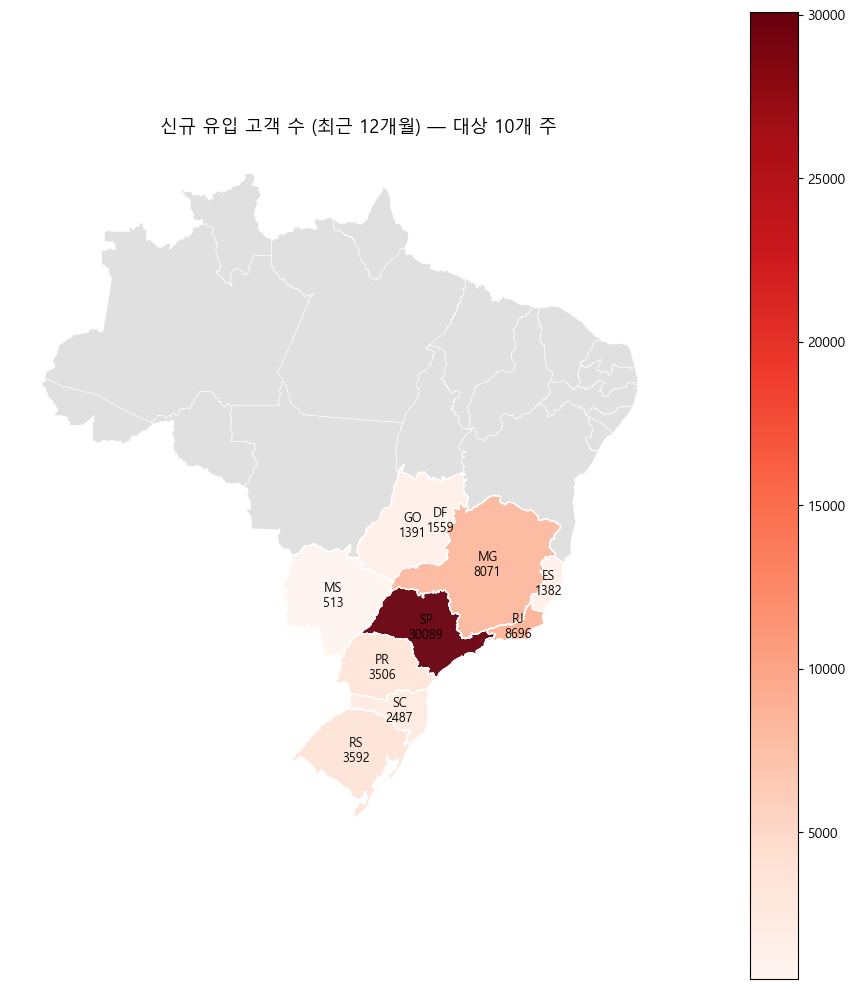

[저장] C:\Users\jmh98\Desktop\archive\map_order_count_only.png


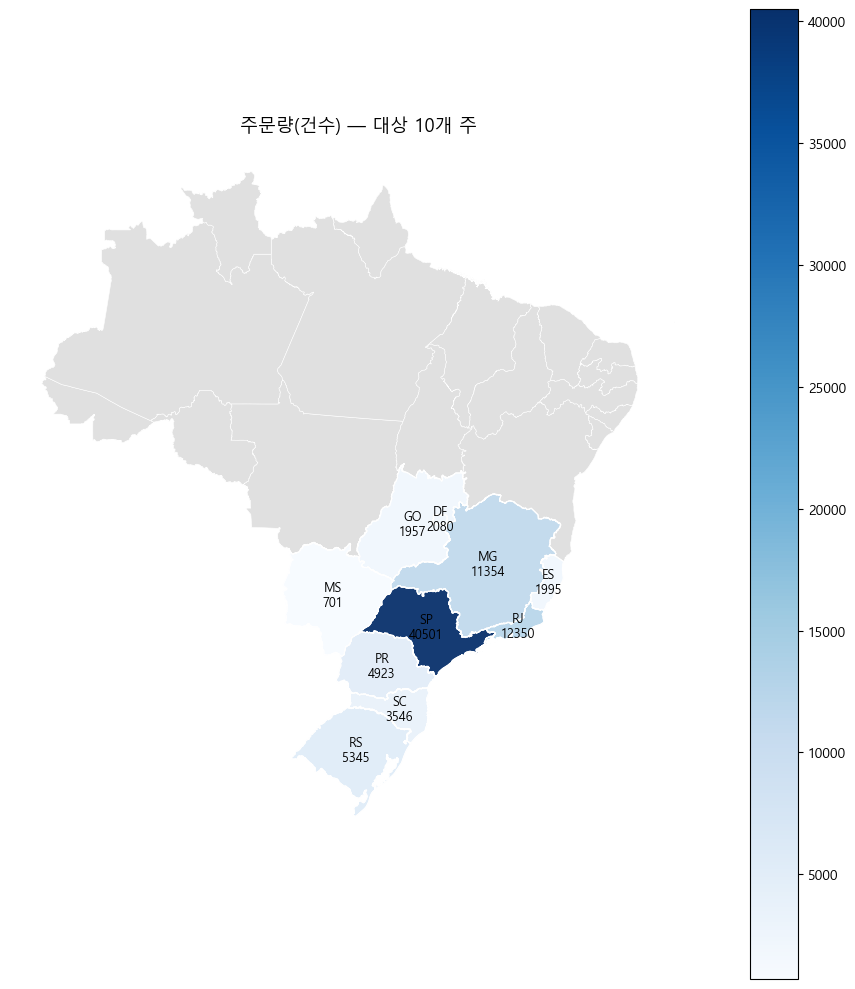

In [149]:
# === 브라질 주별 지도 2장 생성 ===
# 1) 신규 유입 고객 수(최근 12개월) 지도  [붉은계열]
# 2) 주문량(건수) 지도                    [푸른계열]
# - 분석 대상: MS, GO, DF, MG, ES, RJ, SP, PR, SC, RS 만 색상 표시
# - 그 외 주는 연한 회색으로 표시
# - GeoJSON이 없으면 URL에서 자동 로드 후 로컬에 캐시

import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# ---------- 경로/파일 ----------
PATH = r"C:\Users\jmh98\Desktop\archive"
ORDERS_CSV    = fr"{PATH}\olist_orders_dataset.csv"
CUSTOMERS_CSV = fr"{PATH}\olist_customers_dataset.csv"

# 신규 고객 판정: 최근 N개월 내 첫 주문자 (요청: 12개월)
ROLLING_MONTHS = 12

# GeoJSON (브라질 주 경계)
GEOJSON_LOCAL = fr"{PATH}\brazil_states.geojson"
GEOJSON_URL   = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/brazil-states.geojson"

# 출력 파일
OUT_NEW = fr"{PATH}\map_new_customers_count_12m.png"
OUT_ORD = fr"{PATH}\map_order_count_only.png"

# 분석 대상 주(UF 코드)
TARGET_UF = ["MS","GO","DF","MG","ES","RJ","SP","PR","SC","RS"]

# UF -> GeoJSON 주 이름 매핑
UF2NAME = {
    "AC":"Acre","AL":"Alagoas","AP":"Amapá","AM":"Amazonas","BA":"Bahia","CE":"Ceará",
    "DF":"Distrito Federal","ES":"Espírito Santo","GO":"Goiás","MA":"Maranhão",
    "MT":"Mato Grosso","MS":"Mato Grosso do Sul","MG":"Minas Gerais","PA":"Pará",
    "PB":"Paraíba","PR":"Paraná","PE":"Pernambuco","PI":"Piauí","RJ":"Rio de Janeiro",
    "RN":"Rio Grande do Norte","RS":"Rio Grande do Sul","RO":"Rondônia","RR":"Roraima",
    "SC":"Santa Catarina","SP":"São Paulo","SE":"Sergipe","TO":"Tocantins"
}

# ---------- 1) 데이터 로드 ----------
orders = pd.read_csv(
    ORDERS_CSV,
    parse_dates=["order_purchase_timestamp"]
)
customers = pd.read_csv(CUSTOMERS_CSV)  # customer_state 포함

# ---------- 2) 신규 고객 판정 (최근 12개월) ----------
first_order = (
    orders.groupby("customer_id")["order_purchase_timestamp"]
          .min()
          .reset_index(name="first_order")
)
cust = customers.merge(first_order, on="customer_id", how="left")

cutoff = orders["order_purchase_timestamp"].max() - pd.DateOffset(months=ROLLING_MONTHS)
cust["is_new"] = (cust["first_order"] >= cutoff).astype(int)

# ---------- 3) 주별 집계 ----------
agg_cust = (cust.groupby("customer_state")
                 .agg(new_customers=("is_new","sum"),
                      total_customers=("customer_id","nunique"))
                 .reset_index())

orders_state = (
    orders.merge(customers, on="customer_id", how="left")
          .query("order_status == 'delivered'")
          .groupby("customer_state")
          .size()
          .reset_index(name="order_count")
)

stats = agg_cust.merge(orders_state, on="customer_state", how="left").fillna({"order_count":0})
# 지도 표기용으로 이름 컬럼 생성
stats["name"] = stats["customer_state"].map(UF2NAME)

# ---------- 4) GeoJSON 로드 ----------
if os.path.exists(GEOJSON_LOCAL):
    gdf = gpd.read_file(GEOJSON_LOCAL)
else:
    gdf = gpd.read_file(GEOJSON_URL)
    try:
        gdf.to_file(GEOJSON_LOCAL, driver="GeoJSON")
    except Exception:
        pass  # 저장 실패해도 시각화에는 영향 없음

# 주 이름 기준 병합
gdf = gdf.merge(stats, on="name", how="left")

# TARGET 플래그/UF 코드 부여
name2UF = {v:k for k,v in UF2NAME.items()}
gdf["UF"] = gdf["name"].map(name2UF)
gdf["is_target"] = gdf["UF"].isin(TARGET_UF)

# ---------- 공통: 바탕지도(비대상 회색) ----------
def draw_base(ax):
    gdf[~gdf["is_target"]].plot(ax=ax, color="#E0E0E0", edgecolor="white", linewidth=0.4)
    gdf[gdf["is_target"]].boundary.plot(ax=ax, color="white", linewidth=0.8)

# ---------- 5) 지도 1: 신규 유입 고객 수(최근 12개월) ----------
fig, ax = plt.subplots(1,1, figsize=(9,10))
draw_base(ax)

target_new = gdf[gdf["is_target"]].copy()
target_new["new_customers"] = target_new["new_customers"].fillna(0).astype(int)

m1 = target_new.plot(
    ax=ax, column="new_customers", cmap="Reds", legend=True,
    edgecolor="white", linewidth=0.8, alpha=0.95
)

# 라벨: UF / 신규고객수
for _, r in target_new.iterrows():
    if r.geometry is None or r.geometry.is_empty:
        continue
    x, y = r.geometry.centroid.x, r.geometry.centroid.y
    uf = r["UF"]
    nnew = int(r["new_customers"])
    ax.text(x, y, f"{uf}\n{nnew}", ha="center", va="center", fontsize=9)

ax.set_title(f"신규 유입 고객 수 (최근 {ROLLING_MONTHS}개월) — 대상 10개 주", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig(OUT_NEW, dpi=300, bbox_inches="tight")
print(f"[저장] {OUT_NEW}")
plt.show()

# ---------- 6) 지도 2: 주문량(건수) ----------
fig, ax = plt.subplots(1,1, figsize=(9,10))
draw_base(ax)

target_ord = gdf[gdf["is_target"]].copy()
target_ord["order_count"] = target_ord["order_count"].fillna(0).astype(int)

m2 = target_ord.plot(
    ax=ax, column="order_count", cmap="Blues", legend=True,
    edgecolor="white", linewidth=0.8, alpha=0.95
)

# 라벨: UF / 주문수
for _, r in target_ord.iterrows():
    if r.geometry is None or r.geometry.is_empty:
        continue
    x, y = r.geometry.centroid.x, r.geometry.centroid.y
    uf = r["UF"]
    oc = int(r["order_count"])
    ax.text(x, y, f"{uf}\n{oc}", ha="center", va="center", fontsize=9)

ax.set_title("주문량(건수) — 대상 10개 주", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig(OUT_ORD, dpi=300, bbox_inches="tight")
print(f"[저장] {OUT_ORD}")
plt.show()


[저장] k 선택 참고 그래프: C:\Users\jmh98\Desktop\archive\mfc_k_selection.png
[선택된 k] 5 (silhouette 기준)
[저장] 후보 센터 요약: C:\Users\jmh98\Desktop\archive\mfc_candidates.csv
   cluster  center_lat  center_lon  orders  share_%  weighted_mean_km  \
0        0   -23.27458   -46.74944   27746     46.5              69.6   
1        2   -21.50473   -43.12074   15545     26.1             186.7   
2        4   -23.19045   -50.73630    6160     10.3             249.6   
3        1   -28.63925   -51.01200    6150     10.3             222.9   
4        3   -16.83973   -48.06335    4035      6.8             199.7   

   weighted_median_km  
0                44.3  
1               164.7  
2               277.7  
3               197.7  
4               133.3  
[저장] 지도 산점: C:\Users\jmh98\Desktop\archive\mfc_map.png


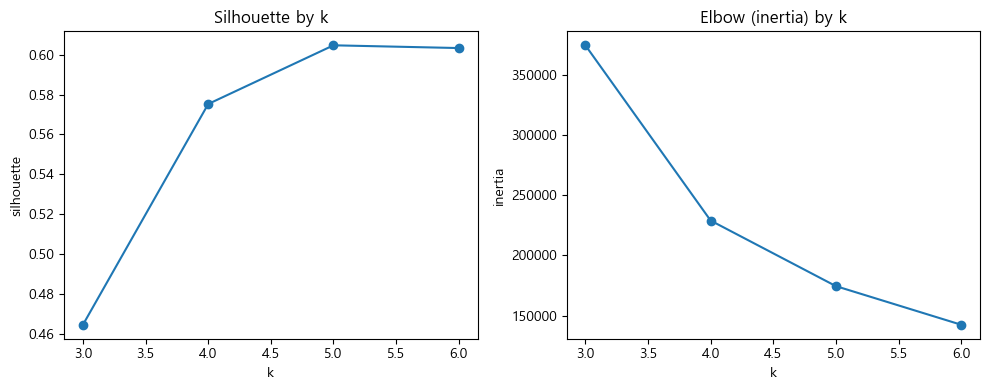

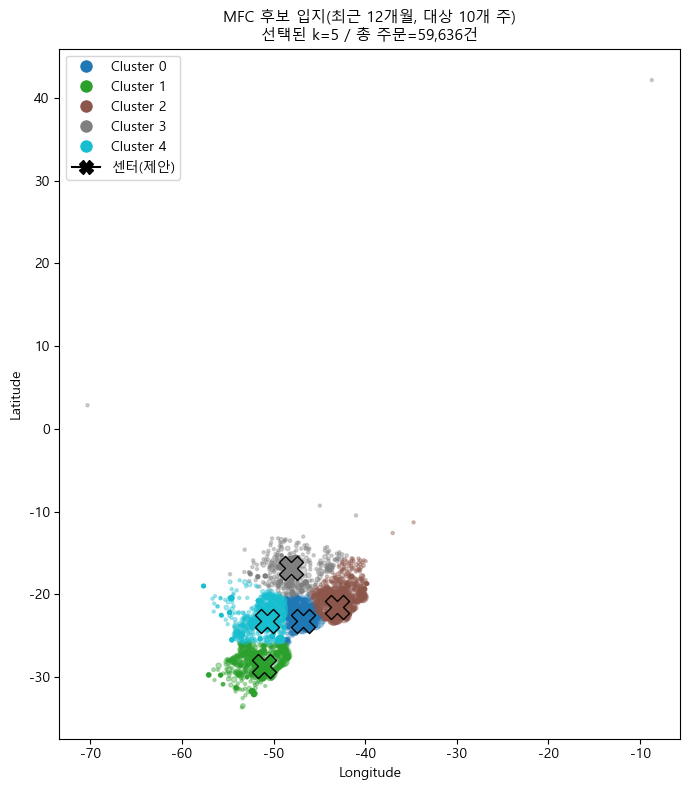

In [150]:
# === Olist: 고객 위경도 + 주문량 기반 MFC 후보 입지 선정 ===
# - 최근 12개월, 대상 10개 주만
# - zipcode prefix → 위경도 매핑으로 고객 좌표 생성
# - 주문건수로 가중치 부여한 KMeans
# - k 후보 3~6 중 실루엣/엘보 보고 자동 추천
# - 결과: 후보 좌표 CSV + 시각화 PNG 저장

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib.lines import Line2D

# -------- 경로 --------
PATH = r"C:\Users\jmh98\Desktop\archive"
ORDERS_CSV    = fr"{PATH}\olist_orders_dataset.csv"
CUSTOMERS_CSV = fr"{PATH}\olist_customers_dataset.csv"
GEO_CSV       = fr"{PATH}\olist_geolocation_dataset.csv"

OUT_CSV = fr"{PATH}\mfc_candidates.csv"
OUT_MAP = fr"{PATH}\mfc_map.png"
OUT_K   = fr"{PATH}\mfc_k_selection.png"

TARGET_UF = ["MS","GO","DF","MG","ES","RJ","SP","PR","SC","RS"]
ROLLING_MONTHS = 12
K_RANGE = range(3, 7)  # 3~6 후보

warnings.filterwarnings("ignore")

# -------- 1) 데이터 로드 --------
orders = pd.read_csv(ORDERS_CSV, parse_dates=["order_purchase_timestamp"])
customers = pd.read_csv(CUSTOMERS_CSV)  # customer_id, customer_state, customer_zip_code_prefix
geo = pd.read_csv(GEO_CSV)              # geolocation_zip_code_prefix, geolocation_lat, geolocation_lng

# -------- 2) 최근 12개월 + 배송완료 + 대상 주 필터 --------
cutoff = orders["order_purchase_timestamp"].max() - pd.DateOffset(months=ROLLING_MONTHS)
ord12 = orders[(orders["order_purchase_timestamp"] >= cutoff) &
               (orders["order_status"] == "delivered")].copy()

ord12 = ord12.merge(customers[["customer_id","customer_state","customer_zip_code_prefix"]],
                    on="customer_id", how="left")

ord12 = ord12[ord12["customer_state"].isin(TARGET_UF)].copy()

# -------- 3) 고객 좌표 만들기 (zipcode prefix 평균 좌표 매핑) --------
# 같은 prefix가 geo에 여러번 등장하므로 평균 사용
geo_zip = (geo.groupby("geolocation_zip_code_prefix")[["geolocation_lat","geolocation_lng"]]
             .mean()
             .rename(columns={"geolocation_lat":"lat","geolocation_lng":"lon"})
             .reset_index())

ord12 = ord12.merge(geo_zip, left_on="customer_zip_code_prefix",
                    right_on="geolocation_zip_code_prefix", how="left")

# 좌표 없는 행 제거
ord12 = ord12.dropna(subset=["lat","lon"]).copy()

# -------- 4) 수요 포인트 집계 (고객 zip prefix 단위) --------
# 한 좌표(=prefix)에서 발생한 주문 수가 가중치
demand = (ord12.groupby(["customer_state","customer_zip_code_prefix","lat","lon"])
                .size()
                .reset_index(name="orders"))

# 표준화 확인을 위해 총 주문량
total_orders = int(demand["orders"].sum())

# -------- 5) k 선택 (실루엣 + 엘보) --------
X = demand[["lat","lon"]].values
W = demand["orders"].values  # 가중치

sil_scores, inertias = [], []
best_k, best_sil = None, -1

# 가중치를 반영하려면 샘플을 orders만큼 복제하면 메모리 비효율 → KMeans에 sample_weight 사용
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X, sample_weight=W)
    labels = km.predict(X)
    # 실루엣은 샘플 가중치 미지원이라 근사로 사용(중요: 대세 판단용)
    try:
        sil = silhouette_score(X, labels, metric="euclidean")
    except Exception:
        sil = np.nan
    sil_scores.append(sil)
    # 엘보(inertia)는 가중치 직접 계산
    inertia = np.sum(km.transform(X)**2 * W.reshape(-1,1)).min(axis=1).sum() if False else km.inertia_
    inertias.append(km.inertia_)
    if (not np.isnan(sil)) and sil > best_sil:
        best_sil = sil
        best_k = k

# k 선택 시각화
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(list(K_RANGE), sil_scores, marker="o")
ax[0].set_title("Silhouette by k"); ax[0].set_xlabel("k"); ax[0].set_ylabel("silhouette")
ax[1].plot(list(K_RANGE), inertias, marker="o")
ax[1].set_title("Elbow (inertia) by k"); ax[1].set_xlabel("k"); ax[1].set_ylabel("inertia")
plt.tight_layout(); plt.savefig(OUT_K, dpi=200)
print(f"[저장] k 선택 참고 그래프: {OUT_K}")

if best_k is None:
    best_k = 4  # 안전 기본값
print(f"[선택된 k] {best_k} (silhouette 기준)")

# -------- 6) 최종 KMeans 학습 & 군집 통계 --------
km = KMeans(n_clusters=best_k, n_init=20, random_state=42)
km.fit(X, sample_weight=W)
centers = km.cluster_centers_
labels = km.predict(X)

demand["cluster"] = labels

# 군집 요약
cluster_sum = (demand.groupby("cluster")
               .agg(orders=("orders","sum"),
                    lat=("lat","mean"), lon=("lon","mean"))
               .reset_index()
               .sort_values("orders", ascending=False)
               .reset_index(drop=True))
cluster_sum["share_%"] = (cluster_sum["orders"] / total_orders * 100).round(1)

# 후보 좌표(센터) 및 커버 반경(중앙값 거리) 계산
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    p = np.pi/180
    a = 0.5 - np.cos((lat2-lat1)*p)/2 + np.cos(lat1*p)*np.cos(lat2*p)*(1-np.cos((lon2-lon1)*p))/2
    return 2*R*np.arcsin(np.sqrt(a))

cent_rows = []
for i, (c_lat, c_lon) in enumerate(centers):
    sub = demand[demand["cluster"]==i].copy()
    dist = haversine(c_lat, c_lon, sub["lat"].values, sub["lon"].values)
    w = sub["orders"].values
    # 가중 평균/중앙값 거리
    wmean = np.average(dist, weights=w) if w.sum()>0 else np.nan
    med = float(np.quantile(np.repeat(dist, w), 0.5)) if w.sum()>0 else np.nan
    ords = int(w.sum())
    pct = ords/total_orders*100 if total_orders>0 else 0
    cent_rows.append({
        "cluster": i,
        "center_lat": round(c_lat, 5),
        "center_lon": round(c_lon, 5),
        "orders": ords,
        "share_%": round(pct, 1),
        "weighted_mean_km": round(wmean, 1),
        "weighted_median_km": round(med, 1),
    })

centers_df = pd.DataFrame(cent_rows).sort_values("orders", ascending=False).reset_index(drop=True)
centers_df.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
print(f"[저장] 후보 센터 요약: {OUT_CSV}")
print(centers_df)

# -------- 7) 지도 시각화(산점+센터표시) --------
# 배경 경계가 없어도 산점만으로 클러스터 구조 파악 가능.
# (이전에 사용한 GeoJSON이 있다면 오버레이 가능)

colors = plt.cm.tab10(np.linspace(0,1,best_k))

fig, ax = plt.subplots(figsize=(7,8))
for i in range(best_k):
    sub = demand[demand["cluster"]==i]
    ax.scatter(sub["lon"], sub["lat"], s=np.clip(sub["orders"], 5, 80), alpha=0.35,
               color=colors[i], label=f"Cluster {i} ({sub['orders'].sum():,} ord)")
    c = centers[i]
    ax.scatter(c[1], c[0], s=300, color=colors[i], edgecolors="black", marker="X", zorder=5)

# 범례 커스터마이즈
handles = [Line2D([0],[0], marker='o', color='w', label=f'Cluster {i}',
                  markerfacecolor=colors[i], markersize=10) for i in range(best_k)]
handles += [Line2D([0],[0], marker='X', color='k', label='센터(제안)', markerfacecolor='k', markersize=10)]
ax.legend(handles=handles, loc="best")
ax.set_title(f"MFC 후보 입지(최근 {ROLLING_MONTHS}개월, 대상 10개 주)\n"
             f"선택된 k={best_k} / 총 주문={total_orders:,}건", fontsize=11)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout(); plt.savefig(OUT_MAP, dpi=200)
print(f"[저장] 지도 산점: {OUT_MAP}")
plt.show()


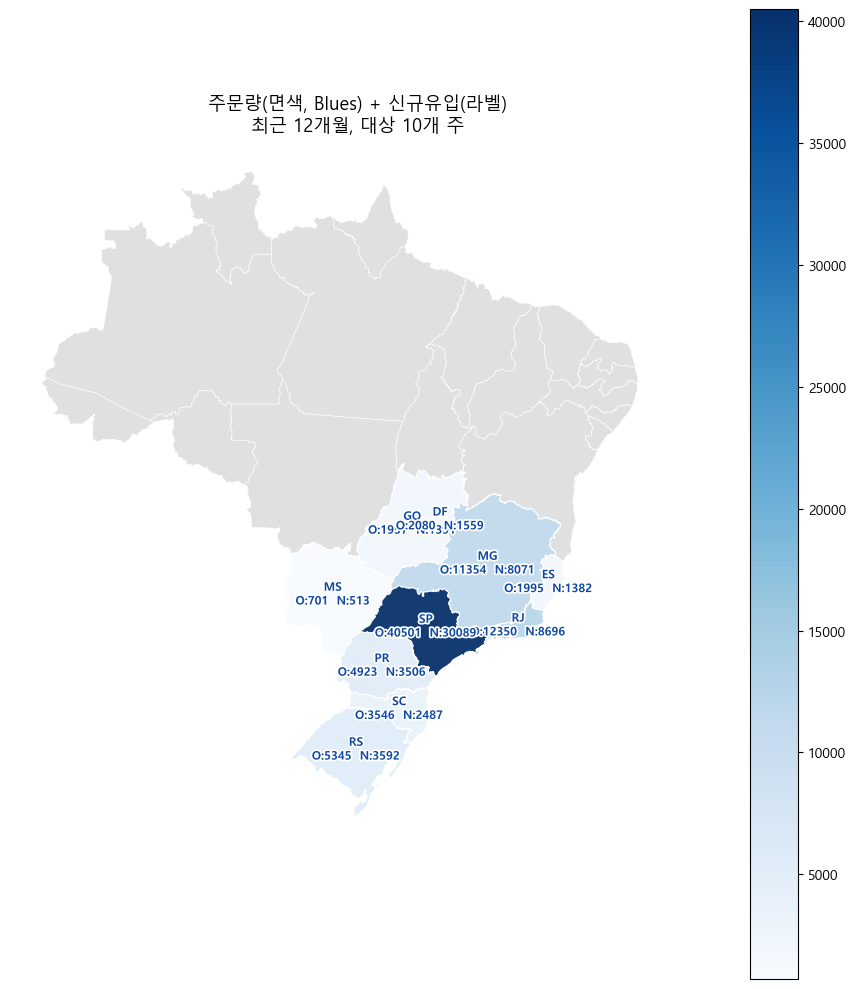

[저장] C:\Users\jmh98\Desktop\archive\map_combo_labels.png


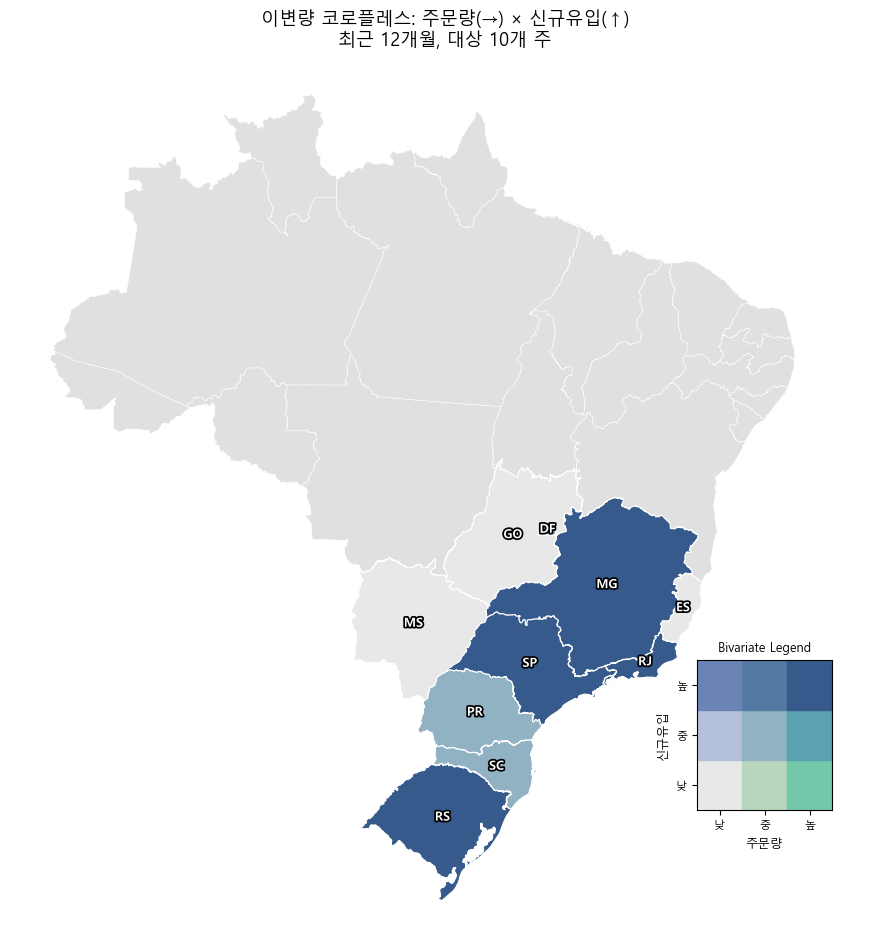

[저장] C:\Users\jmh98\Desktop\archive\map_combo_bivariate.png


In [155]:
# === Olist: '주문량 vs 신규유입' 결합 시각화 2종 ===
# - A) 면색=주문량 + 라벨=신규/주문량 숫자
# - B) 이변량 코로플레스(3x3 팔레트)
# - 최근 12개월, 대상 10개 주만 강조, 그 외 회색

import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np

# ---------- 경로 ----------
PATH = r"C:\Users\jmh98\Desktop\archive"
ORDERS = fr"{PATH}\olist_orders_dataset.csv"
CUSTOMERS = fr"{PATH}\olist_customers_dataset.csv"
GEOJSON_LOCAL = fr"{PATH}\brazil_states.geojson"
GEOJSON_URL   = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/brazil-states.geojson"

OUT_A = fr"{PATH}\map_combo_labels.png"
OUT_B = fr"{PATH}\map_combo_bivariate.png"

TARGET_UF = ["MS","GO","DF","MG","ES","RJ","SP","PR","SC","RS"]
ROLLING_MONTHS = 12

UF2NAME = {
    "AC":"Acre","AL":"Alagoas","AP":"Amapá","AM":"Amazonas","BA":"Bahia","CE":"Ceará",
    "DF":"Distrito Federal","ES":"Espírito Santo","GO":"Goiás","MA":"Maranhão",
    "MT":"Mato Grosso","MS":"Mato Grosso do Sul","MG":"Minas Gerais","PA":"Pará",
    "PB":"Paraíba","PR":"Paraná","PE":"Pernambuco","PI":"Piauí","RJ":"Rio de Janeiro",
    "RN":"Rio Grande do Norte","RS":"Rio Grande do Sul","RO":"Rondônia","RR":"Roraima",
    "SC":"Santa Catarina","SP":"São Paulo","SE":"Sergipe","TO":"Tocantins"
}
name2UF = {v:k for k,v in UF2NAME.items()}

# ---------- 데이터 로드/집계(최근 12개월) ----------
orders = pd.read_csv(ORDERS, parse_dates=["order_purchase_timestamp"])
customers = pd.read_csv(CUSTOMERS)

cutoff = orders["order_purchase_timestamp"].max() - pd.DateOffset(months=ROLLING_MONTHS)

first_order = (orders.groupby("customer_id")["order_purchase_timestamp"]
                      .min().reset_index(name="first_order"))
cust = customers.merge(first_order, on="customer_id", how="left")
cust["is_new"] = (cust["first_order"] >= cutoff).astype(int)

agg_cust = (cust.groupby("customer_state")
                 .agg(new_customers=("is_new","sum"),
                      total_customers=("customer_id","nunique"))
                 .reset_index())

orders_state = (orders.merge(customers, on="customer_id", how="left")
                      .query("order_status == 'delivered'")
                      .groupby("customer_state").size()
                      .reset_index(name="order_count"))

stats = agg_cust.merge(orders_state, on="customer_state", how="left").fillna({"order_count":0})
stats["name"] = stats["customer_state"].map(UF2NAME)

# ---------- 지도 로드 & 머지 ----------
if os.path.exists(GEOJSON_LOCAL):
    gdf = gpd.read_file(GEOJSON_LOCAL)
else:
    gdf = gpd.read_file(GEOJSON_URL)
    try:
        gdf.to_file(GEOJSON_LOCAL, driver="GeoJSON")
    except Exception:
        pass

gdf = gdf.merge(stats, on="name", how="left")
gdf["UF"] = gdf["name"].map(name2UF)
gdf["is_target"] = gdf["UF"].isin(TARGET_UF)

def draw_base(ax):
    gdf[~gdf["is_target"]].plot(ax=ax, color="#E0E0E0", edgecolor="white", linewidth=0.4)

# ======================
# A) 면색=주문량 + 라벨=숫자
# ======================
fig, ax = plt.subplots(1,1, figsize=(9,10))
draw_base(ax)

g_tgt = gdf[gdf["is_target"]].copy()
g_tgt["order_count"] = g_tgt["order_count"].fillna(0).astype(int)
g_tgt["new_customers"] = g_tgt["new_customers"].fillna(0).astype(int)

# 면색(주문량)
m = g_tgt.plot(ax=ax, column="order_count", cmap="Blues",
               legend=True, edgecolor="white", linewidth=0.8, alpha=0.95)

# 라벨 (숫자) – 흰색 윤곽선(halo) 넣어서 가독성 ↑
halo = [pe.withStroke(linewidth=2.5, foreground="white")]
for _, r in g_tgt.iterrows():
    x, y = r.geometry.centroid.x, r.geometry.centroid.y
    ax.text(x, y,
            f"{r['UF']}\nO:{int(r['order_count'])}  N:{int(r['new_customers'])}",
            ha="center", va="center",
            fontsize=8.5, color="#0D47A1", weight="bold",
            path_effects=halo)

ax.set_title(f"주문량(면색, Blues) + 신규유입(라벨)\n최근 {ROLLING_MONTHS}개월, 대상 10개 주", fontsize=13)
ax.axis("off")
plt.tight_layout(); plt.savefig(OUT_A, dpi=300, bbox_inches="tight"); plt.show()
print(f"[저장] {OUT_A}")

# ======================
# B) 이변량 코로플레스(3x3)
# ======================
def quantile_bins(series, q=3):
    qs = series.quantile([i/q for i in range(1,q)]).values
    return np.digitize(series, qs) + 1

gt = g_tgt.copy()
gt["q_ord"] = quantile_bins(gt["order_count"], q=3)
gt["q_new"] = quantile_bins(gt["new_customers"], q=3)

palette = {
    (1,1): "#e8e8e8", (2,1): "#b8d6be", (3,1): "#73c8a9",
    (1,2): "#b5c0da", (2,2): "#90b2c3", (3,2): "#5aa2b1",
    (1,3): "#6c83b5", (2,3): "#5479a3", (3,3): "#365a8c",
}
gt["bivar_col"] = [palette[(int(o), int(n))] for o, n in zip(gt["q_ord"], gt["q_new"])]

fig, ax = plt.subplots(1,1, figsize=(9,10))
draw_base(ax)
gt.plot(ax=ax, color=gt["bivar_col"], edgecolor="white", linewidth=0.8)

# 라벨 – UF만 표시, 흰색 halo 처리
halo = [pe.withStroke(linewidth=2.5, foreground="black")]
for _, r in gt.iterrows():
    x, y = r.geometry.centroid.x, r.geometry.centroid.y
    ax.text(x, y, r["UF"],
            ha="center", va="center", fontsize=9,
            color="white", weight="bold", path_effects=halo)

ax.set_title(f"이변량 코로플레스: 주문량(→) × 신규유입(↑)\n최근 {ROLLING_MONTHS}개월, 대상 10개 주", fontsize=13)
ax.axis("off")

from matplotlib.patches import Rectangle
legend_ax = fig.add_axes([0.78, 0.18, 0.15, 0.15])
for i in range(1,4):
    for j in range(1,4):
        legend_ax.add_patch(Rectangle((i-1, j-1), 1, 1, color=palette[(i,j)]))
legend_ax.set_xticks([0.5,1.5,2.5]); legend_ax.set_xticklabels(["낮","중","높"], fontsize=8)
legend_ax.set_yticks([0.5,1.5,2.5]); legend_ax.set_yticklabels(["낮","중","높"], fontsize=8)
legend_ax.set_xlabel("주문량", fontsize=9); legend_ax.set_ylabel("신규유입", fontsize=9)
legend_ax.set_title("Bivariate Legend", fontsize=9)
legend_ax.set_xlim(0,3); legend_ax.set_ylim(0,3)

plt.tight_layout(); plt.savefig(OUT_B, dpi=300, bbox_inches="tight"); plt.show()
print(f"[저장] {OUT_B}")


In [163]:
# ---------- 절댓값 구간: Top-sliced 방식 (1위=높음, 2~3위=중간, 그외=낮음) ----------
def top_sliced_bins(series_target10, top_high=1, top_mid=3):
    """
    series_target10: 대상 10개 주의 절댓값 시리즈 (ex. 주문량 or 신규유입)
    top_high: 상위 몇 개를 '높음(3)'에 넣을지
    top_mid : 상위 몇 개까지를 '중간(2)'에 넣을지 (ex. 3이면 2~3위가 중간)
    반환: [0, 중간 상한, 높음 하한, inf] 형태의 절댓값 경계
    """
    s = series_target10.sort_values(ascending=False).reset_index(drop=True)
    # 안전장치
    if len(s) < top_mid:
        return [0, float(s.min()), float(s.max()), float('inf')]

    # 경계는 '값 + 아주 작은 값'으로 겹침 방지
    eps = 1e-6
    # 낮음/중간 경계 = (top_mid위 값) + eps
    low_mid = float(s.iloc[top_mid-1]) + eps
    # 중간/높음 경계 = (top_high위 값) + eps
    mid_high = float(s.iloc[top_high-1]) + eps

    # 오름차순 경계 반환
    edges = [0.0, low_mid, mid_high, float('inf')]
    # 경계가 뒤집히지 않도록 정렬
    edges = sorted(edges)
    return edges

# 주문량/신규유입의 대상 10개 값으로 절댓값 경계 계산
ord_bins = top_sliced_bins(g.loc[g["is_target10"], "order_count"], top_high=1, top_mid=3)
new_bins = top_sliced_bins(g.loc[g["is_target10"], "new_customers"], top_high=1, top_mid=3)

# 필요 시, 직접 경계 고정하고 싶으면 아래 두 줄을 주석 해제해 원하는 값으로 덮어쓰세요.
# ord_bins = [0, 8000, 20000, float('inf')]
# new_bins = [0, 8000, 20000, float('inf')]

# 구간 부여 (1,2,3)
g["bin_ord"] = pd.cut(g["order_count"],   bins=ord_bins, labels=[1,2,3],
                      right=False, include_lowest=True).astype(int)
g["bin_new"] = pd.cut(g["new_customers"], bins=new_bins, labels=[1,2,3],
                      right=False, include_lowest=True).astype(int)

# (범례 라벨도 새 경계로 갱신)
def bins_to_labels(edges):
    out = []
    for i in range(len(edges)-1):
        a, b = edges[i], edges[i+1]
        a_txt = f"{int(a):,}" if np.isfinite(a) else "0"
        b_txt = "∞" if not np.isfinite(b) else f"{int(b):,}"
        out.append(f"{a_txt}–{b_txt}")
    return out

x_labels = bins_to_labels(ord_bins)
y_labels = bins_to_labels(new_bins)


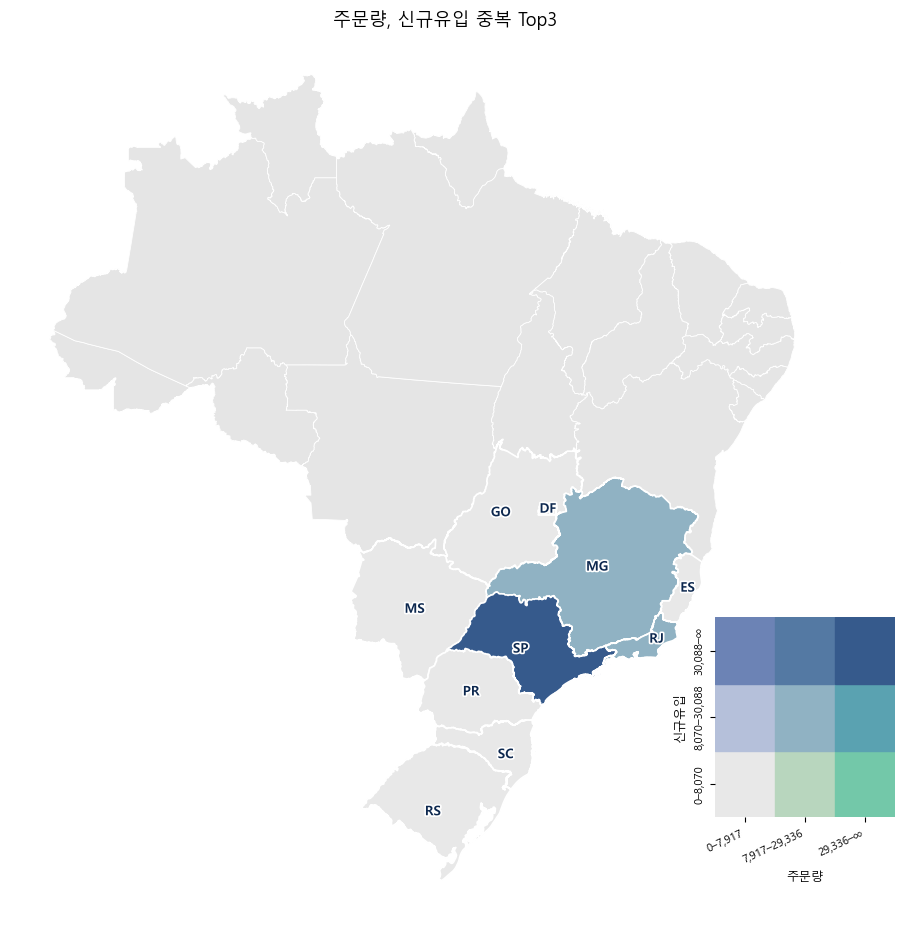

[저장] C:\Users\jmh98\Desktop\archive\map_bivariate_top_sliced_fixed.png

[점검] SP/MG/RJ 절댓값 & 구간
    UF  order_count  new_customers  bin_ord  bin_new bivar_col
9   MG         7918           8071        2        2   #90b2c3
17  RJ         8389           8696        2        2   #90b2c3
24  SP        29337          30089        3        3   #365a8c

ord_bins: [0.0, 7917.999999, 29336.999999, inf]
new_bins: [0.0, 8070.999999, 30088.999999, inf]


In [170]:
# === Bivariate Choropleth (절댓값 Top-sliced + 경계 보정) ===
# - 주문량(→) × 신규유입(↑) 3×3 팔레트
# - 상위 1개 = 높음(3), 2~3위 = 중간(2), 그 외 = 낮음(1)
# - 경계값 보정으로 MG/RJ도 확실히 색상 배정
import os, math
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Rectangle

# ---------- 경로 ----------
PATH = r"C:\Users\jmh98\Desktop\archive"
ORDERS = fr"{PATH}\olist_orders_dataset.csv"
CUSTOMERS = fr"{PATH}\olist_customers_dataset.csv"
GEOJSON_LOCAL = fr"{PATH}\brazil_states.geojson"
GEOJSON_URL   = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/brazil-states.geojson"
OUT_PNG = fr"{PATH}\map_bivariate_top_sliced_fixed.png"

ROLLING_MONTHS = 12
TARGET_UF = ["MS","GO","DF","MG","ES","RJ","SP","PR","SC","RS"]

# ---------- UF <-> name ----------
UF2NAME = {
    "AC":"Acre","AL":"Alagoas","AP":"Amapá","AM":"Amazonas","BA":"Bahia","CE":"Ceará",
    "DF":"Distrito Federal","ES":"Espírito Santo","GO":"Goiás","MA":"Maranhão",
    "MT":"Mato Grosso","MS":"Mato Grosso do Sul","MG":"Minas Gerais","PA":"Pará",
    "PB":"Paraíba","PR":"Paraná","PE":"Pernambuco","PI":"Piauí","RJ":"Rio de Janeiro",
    "RN":"Rio Grande do Norte","RS":"Rio Grande do Sul","RO":"Rondônia","RR":"Roraima",
    "SC":"Santa Catarina","SP":"São Paulo","SE":"Sergipe","TO":"Tocantins"
}
NAME2UF = {v:k for k,v in UF2NAME.items()}

# ---------- 데이터 로드 ----------
orders = pd.read_csv(ORDERS, parse_dates=["order_purchase_timestamp"])
customers = pd.read_csv(CUSTOMERS)

cutoff = orders["order_purchase_timestamp"].max() - pd.DateOffset(months=ROLLING_MONTHS)

# 신규 판별
first_order = orders.groupby("customer_id")["order_purchase_timestamp"].min().reset_index(name="first_order")
cust = customers.merge(first_order, on="customer_id", how="left")
cust["is_new"] = (cust["first_order"] >= cutoff).astype(int)

agg_cust = (cust.groupby("customer_state")
                 .agg(new_customers=("is_new","sum"),
                      total_customers=("customer_id","nunique"))
                 .reset_index()
                 .rename(columns={"customer_state":"UF"}))

orders_12 = orders[(orders["order_purchase_timestamp"]>=cutoff) & (orders["order_status"]=="delivered")]
orders_state = (orders_12.merge(customers, on="customer_id", how="left")
                        .groupby("customer_state").size()
                        .reset_index(name="order_count")
                        .rename(columns={"customer_state":"UF"}))

stats = (agg_cust.merge(orders_state, on="UF", how="outer")
               .fillna({"new_customers":0, "order_count":0})
               .astype({"new_customers":int, "order_count":int}))
stats["name"] = stats["UF"].map(UF2NAME)

# ---------- GeoJSON ----------
if os.path.exists(GEOJSON_LOCAL):
    gdf = gpd.read_file(GEOJSON_LOCAL)
else:
    gdf = gpd.read_file(GEOJSON_URL)
    try: gdf.to_file(GEOJSON_LOCAL, driver="GeoJSON")
    except: pass

gdf["UF"] = gdf["name"].map(NAME2UF)
g = gdf.merge(stats, on="UF", how="left")
g["is_target10"]   = g["UF"].isin(TARGET_UF)
g["order_count"]   = g["order_count"].fillna(0).astype(int)
g["new_customers"] = g["new_customers"].fillna(0).astype(int)

# ---------- 절댓값 구간 (Top-sliced + eps 보정) ----------
def top_sliced_bins(series_target10, top_high=1, top_mid=3, eps=1e-6):
    s = series_target10.sort_values(ascending=False).reset_index(drop=True)
    if len(s) == 0:
        return [0, 1, 2, float('inf')]
    # 경계값과 '같은 값'이 아래 구간으로 빠지지 않도록 경계치를 살짝 낮춤
    mid_hi  = float(s.iloc[min(top_high-1, len(s)-1)]) - eps   # 1위 경계 ↓
    low_mid = float(s.iloc[min(top_mid-1,  len(s)-1)]) - eps   # 3위 경계 ↓
    edges = sorted([0.0, low_mid, mid_hi, float('inf')])
    return edges

ord_bins = top_sliced_bins(g.loc[g["is_target10"], "order_count"],   top_high=1, top_mid=3)
new_bins = top_sliced_bins(g.loc[g["is_target10"], "new_customers"], top_high=1, top_mid=3)

# 경계 포함 방향을 오른쪽 닫힘으로: 값 == 경계 → '위 구간'에 포함
g["bin_ord"] = pd.cut(g["order_count"],   bins=ord_bins, labels=[1,2,3],
                      right=True, include_lowest=True).astype(int)
g["bin_new"] = pd.cut(g["new_customers"], bins=new_bins, labels=[1,2,3],
                      right=True, include_lowest=True).astype(int)

# ---------- 3×3 팔레트 (x=주문량→, y=신규↑) ----------
palette = {
    (1,1): "#e8e8e8", (2,1): "#b8d6be", (3,1): "#73c8a9",
    (1,2): "#b5c0da", (2,2): "#90b2c3", (3,2): "#5aa2b1",
    (1,3): "#6c83b5", (2,3): "#5479a3", (3,3): "#365a8c",
}
g["bivar_col"] = [palette[(int(o), int(n))] for o, n in zip(g["bin_ord"], g["bin_new"])]

# ---------- 플롯 ----------
fig, ax = plt.subplots(1,1, figsize=(9,10))
g[~g["is_target10"]].plot(ax=ax, color="#E5E5E5", edgecolor="white", linewidth=0.6, zorder=0)
g[g["is_target10"]].plot(ax=ax, color=g.loc[g["is_target10"], "bivar_col"],
                         edgecolor="white", linewidth=1.2, zorder=1)

# UF 라벨(halo)
halo = [pe.withStroke(linewidth=2.4, foreground="white")]
for _, r in g[g["is_target10"]].iterrows():
    p = r.geometry.representative_point()
    ax.text(p.x, p.y, r["UF"], ha="center", va="center", fontsize=9.5,
            color="#0D284F", weight="bold", path_effects=halo)

ax.set_title(f"주문량, 신규유입 중복 Top3",
             fontsize=13)
ax.axis("off")

# ---------- 범례 ----------
def bins_to_labels(edges):
    out = []
    for i in range(len(edges)-1):
        a, b = edges[i], edges[i+1]
        a_txt = f"{int(a):,}" if np.isfinite(a) else "0"
        b_txt = "∞" if not np.isfinite(b) else f"{int(b):,}"
        out.append(f"{a_txt}–{b_txt}")
    return out

x_labels = bins_to_labels(ord_bins)
y_labels = bins_to_labels(new_bins)

legend_ax = fig.add_axes([0.8, 0.16, 0.20, 0.20])
for i in range(1,4):
    for j in range(1,4):
        legend_ax.add_patch(Rectangle((i-1, j-1), 1, 1, color=palette[(i,j)]))
legend_ax.set_xticks([0.5,1.5,2.5]); legend_ax.set_xticklabels(x_labels, fontsize=8, rotation=25, ha="right")
legend_ax.set_yticks([0.5,1.5,2.5]); legend_ax.set_yticklabels(y_labels, fontsize=8, rotation=90, va="center")
legend_ax.set_xlabel("주문량", fontsize=9); legend_ax.set_ylabel("신규유입", fontsize=9)
legend_ax.set_xlim(0,3); legend_ax.set_ylim(0,3)
for s in legend_ax.spines.values(): s.set_visible(False)

plt.tight_layout(); plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight"); plt.show()
print(f"[저장] {OUT_PNG}")

# ---------- 빠른 점검 ----------
print("\n[점검] SP/MG/RJ 절댓값 & 구간")
print(g.loc[g["UF"].isin(['SP','MG','RJ']),
            ['UF','order_count','new_customers','bin_ord','bin_new','bivar_col']]
      .sort_values('UF'))
print("\nord_bins:", ord_bins)
print("new_bins:", new_bins)


In [176]:
import os, numpy as np, pandas as pd, geopandas as gpd

# ---------------- 경로 ----------------
PATH = r"C:\Users\jmh98\Desktop\archive"
GEOJSON_LOCAL = fr"{PATH}\brazil_states.geojson"
GEOJSON_URL   = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/brazil-states.geojson"

# ---------------- 파라미터 ----------------
SOURCE = "SP"                 # 소스(셀러 주)
DEST_UF = ["SE","AL","CE","AP","RR"]   # 목적 주
HUB_LAT, HUB_LON = -5.0, -42.7         # 허브 위치

# ---------------- Geo 준비 ----------------
if os.path.exists(GEOJSON_LOCAL):
    states = gpd.read_file(GEOJSON_LOCAL)
else:
    states = gpd.read_file(GEOJSON_URL)
    try: states.to_file(GEOJSON_LOCAL, driver="GeoJSON")
    except: pass

UF2NAME = {
    "AC":"Acre","AL":"Alagoas","AP":"Amapá","AM":"Amazonas","BA":"Bahia","CE":"Ceará",
    "DF":"Distrito Federal","ES":"Espírito Santo","GO":"Goiás","MA":"Maranhão",
    "MT":"Mato Grosso","MS":"Mato Grosso do Sul","MG":"Minas Gerais","PA":"Pará",
    "PB":"Paraíba","PR":"Paraná","PE":"Pernambuco","PI":"Piauí","RJ":"Rio de Janeiro",
    "RN":"Rio Grande do Norte","RS":"Rio Grande do Sul","RO":"Rondônia","RR":"Roraima",
    "SC":"Santa Catarina","SP":"São Paulo","SE":"Sergipe","TO":"Tocantins"
}
NAME2UF = {v:k for k,v in UF2NAME.items()}
states["UF"] = states["name"].map(NAME2UF)

states = states.to_crs(4326)
rp = states.representative_point()
states["lon"] = rp.x
states["lat"] = rp.y
coords = states.set_index("UF")[["lat","lon"]].to_dict(orient="index")

# ---------------- 거리 함수 ----------------
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1,lon1,lat2,lon2])
    dlat = lat2-lat1; dlon = lon2-lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return float(2*R*np.arcsin(np.sqrt(a)))

# ---------------- 거리 계산 ----------------
rows = []
for d in DEST_UF:
    km_direct = haversine_km(coords[SOURCE]["lat"], coords[SOURCE]["lon"],
                             coords[d]["lat"], coords[d]["lon"])
    km_hub = haversine_km(HUB_LAT, HUB_LON, coords[d]["lat"], coords[d]["lon"])
    rows.append({
        "dest": d,
        "km_direct": round(km_direct,1),
        "km_hub": round(km_hub,1),
        "saving_km": round(km_direct - km_hub,1),
        "saving_pct": round(100*(km_direct - km_hub)/km_direct,1)
    })

res = pd.DataFrame(rows)
print("=== SP 직배송 vs 허브(-5.0,-42.7) 기준 거리 비교 ===")
print(res.to_string(index=False))

print("\n=== 목적 5개 주 평균 ===")
print(f"직배송 평균: {res['km_direct'].mean():.1f} km")
print(f"허브 기준 평균: {res['km_hub'].mean():.1f} km")
print(f"절감률 평균: {res['saving_pct'].mean():.1f}%")


=== SP 직배송 vs 허브(-5.0,-42.7) 기준 거리 비교 ===
dest  km_direct  km_hub  saving_km  saving_pct
  SE     1849.9   866.6      983.4        53.2
  AL     1958.5   841.7     1116.8        57.0
  CE     2187.8   370.8     1816.9        83.0
  AP     2701.8  1268.1     1433.6        53.1
  RR     3007.4  2191.5      816.0        27.1

=== 목적 5개 주 평균 ===
직배송 평균: 2341.1 km
허브 기준 평균: 1107.7 km
절감률 평균: 54.7%


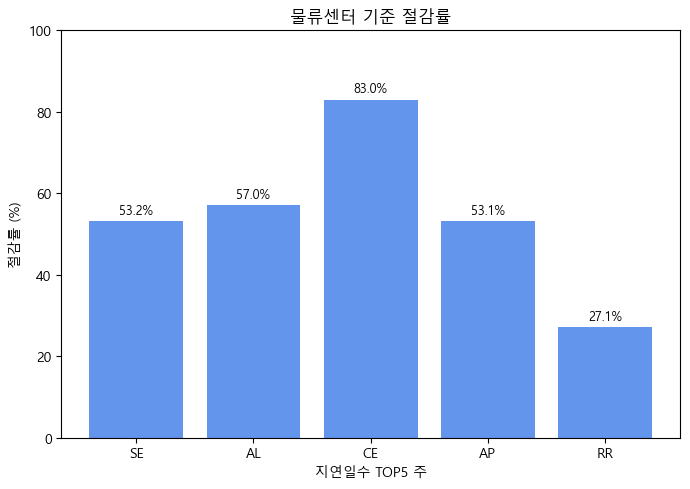

[저장 완료] C:\Users\jmh98\Desktop\archive\hub_saving_comparison.png


In [190]:
import matplotlib.pyplot as plt
import pandas as pd

# 데이터 (SP vs 허브 -5.0,-42.7 기준 결과값)
data = {
    "dest": ["SE", "AL", "CE", "AP", "RR"],
    "saving_pct": [53.2, 57.0, 83.0, 53.1, 27.1]
}
df = pd.DataFrame(data)

# Figure 생성
fig, ax = plt.subplots(figsize=(7,5))

# 절감률(%) 그래프
bars = ax.bar(df["dest"], df["saving_pct"], color="cornflowerblue")
ax.set_title("물류센터 기준 절감률", fontsize=12)
ax.set_xlabel("지연일수 TOP5 주")
ax.set_ylabel("절감률 (%)")
ax.set_ylim(0, 100)

# 값 라벨 표시
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1,
            f"{height:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()

# ---------------- 이미지 저장 ----------------
out_path = r"C:\Users\jmh98\Desktop\archive\hub_saving_comparison.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"[저장 완료] {out_path}")


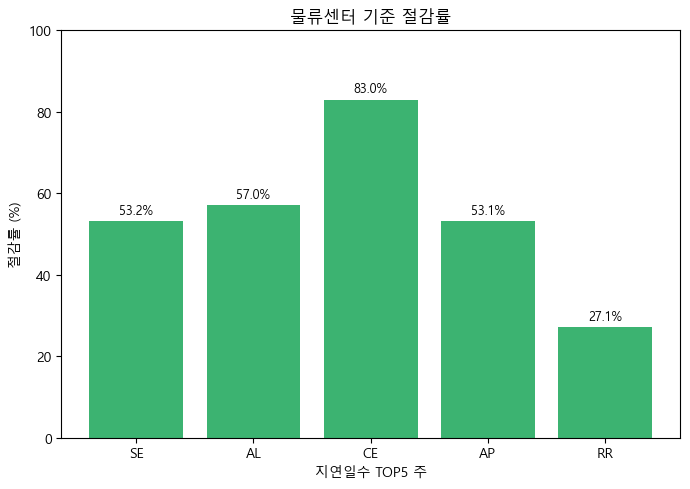

[저장 완료] C:\Users\jmh98\Desktop\archive\hub_saving_comparison2.png


In [191]:
import matplotlib.pyplot as plt
import pandas as pd

# 데이터 (SP vs 허브 -5.0,-42.7 기준 결과값)
data = {
    "dest": ["SE", "AL", "CE", "AP", "RR"],
    "saving_pct": [53.2, 57.0, 83.0, 53.1, 27.1]
}
df = pd.DataFrame(data)

# Figure 생성
fig, ax = plt.subplots(figsize=(7,5))

# 절감률(%) 그래프 (색상 mediumseagreen 사용)
bars = ax.bar(df["dest"], df["saving_pct"], color="mediumseagreen")

ax.set_title("물류센터 기준 절감률", fontsize=12)
ax.set_xlabel("지연일수 TOP5 주")
ax.set_ylabel("절감률 (%)")
ax.set_ylim(0, 100)

# 값 라벨 표시
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1,
            f"{height:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()

# ---------------- 이미지 저장 ----------------
out_path = r"C:\Users\jmh98\Desktop\archive\hub_saving_comparison2.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"[저장 완료] {out_path}")
